In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import matplotlib.ticker as mtick

train_df = pd.read_csv('/kaggle/input/competitions/credit-safe-predicting-loan-default-risk2/cs-training (1).csv')
test_df = pd.read_csv('/kaggle/input/competitions/credit-safe-predicting-loan-default-risk2/cs-test (1).csv')

print(train_df.shape, test_df.shape)
train_df.head()


# ── 4. Model Comparison ──────────────────────────────────────

# ── 5. Interpretation & Reflection ──────────────────────────

# ── Submission ───────────────────────────────────────────────
# submission = pd.DataFrame({'id': test['id'],
# 'default_probability': probs,
# 'predicted_label': preds})
# submission.to_csv('predictions.csv', index=False)

(112500, 12) (37500, 11)


,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,140301,0.034949,60,0,0.004933,8311.0,5,0,0,0,0.0,0
1,92418,0.155308,46,0,881.000000,NaN,6,0,1,0,0.0,0
2,48194,0.165166,63,1,0.020327,3000.0,8,0,0,0,0.0,0
3,66645,0.010886,60,0,0.642979,1167.0,6,0,1,0,0.0,0
4,144735,0.000717,48,0,3603.000000,NaN,15,0,3,0,0.0,0


── 1. Exploratory Data Analysis ─────────────────────────────

1.1 Missingness Audit
Begin by identifying which features have missing values, their exact counts and proportions, and whether the missingness pattern carries information about the target.



In [2]:
# ── Missing value counts and percentages ───────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': train_df.isnull().sum(),
    'Missing %': (train_df.isnull().mean() * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print('Missing Value Summary:')
print(missing)

Missing Value Summary:
                                      Missing Count  Missing %
MonthlyIncome                                 22187      19.72
NumberOfDependents                             2945       2.62
Id                                                0       0.00
RevolvingUtilizationOfUnsecuredLines              0       0.00
NumberOfTime30-59DaysPastDueNotWorse              0       0.00
age                                               0       0.00
NumberOfOpenCreditLinesAndLoans                   0       0.00
DebtRatio                                         0       0.00
NumberOfTimes90DaysLate                           0       0.00
NumberRealEstateLoansOrLines                      0       0.00
NumberOfTime60-89DaysPastDueNotWorse              0       0.00
SeriousDlqin2yrs                                  0       0.00


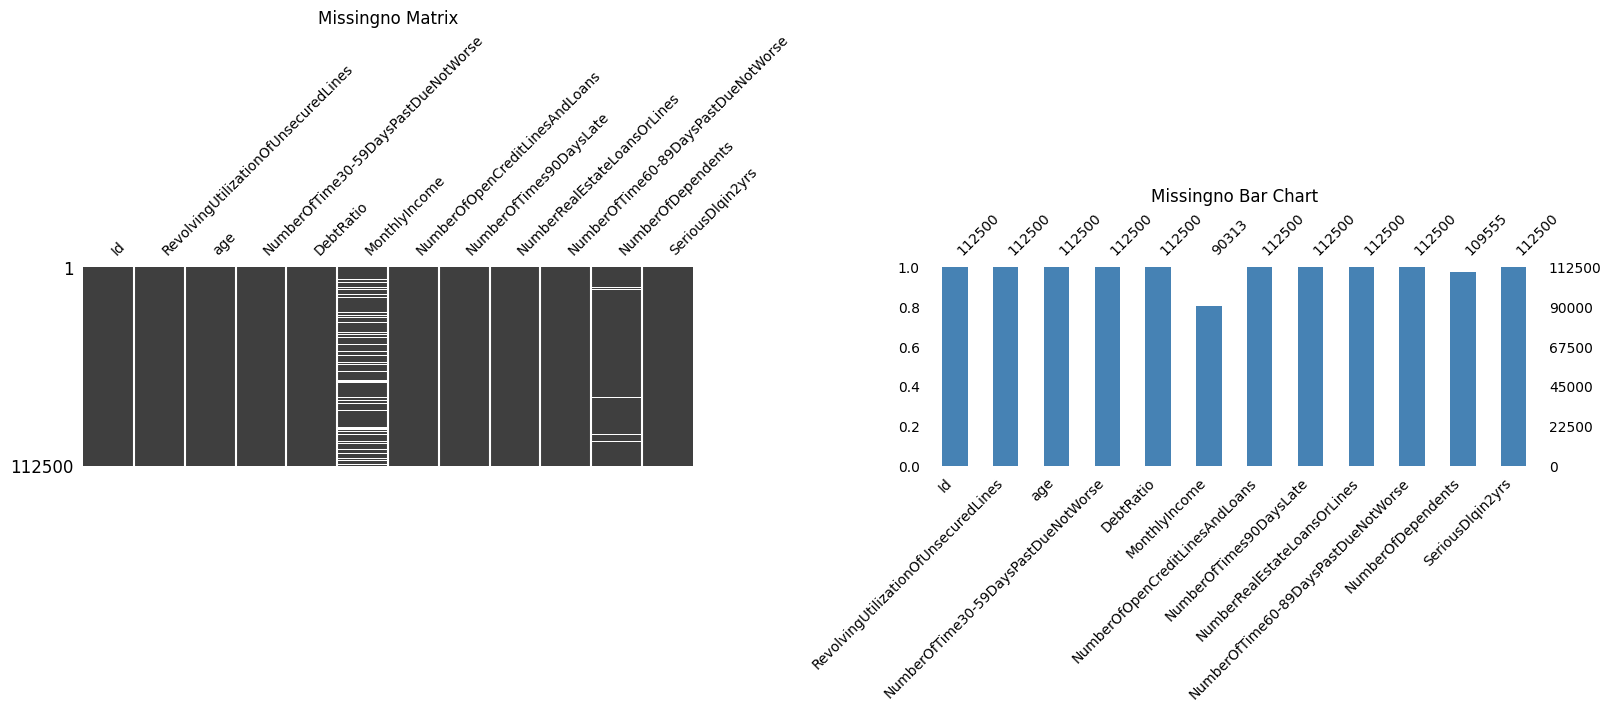

In [3]:
# ── missingno matrix ───────────────────────────────────────────────────────────
# Shows co-occurrence of missingness across rows
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

msno.matrix(train_df, ax=axes[0], sparkline=False, fontsize=10)
axes[0].set_title('Missingno Matrix')

msno.bar(train_df, ax=axes[1], fontsize=10, color='steelblue')
axes[1].set_title('Missingno Bar Chart')

plt.show()

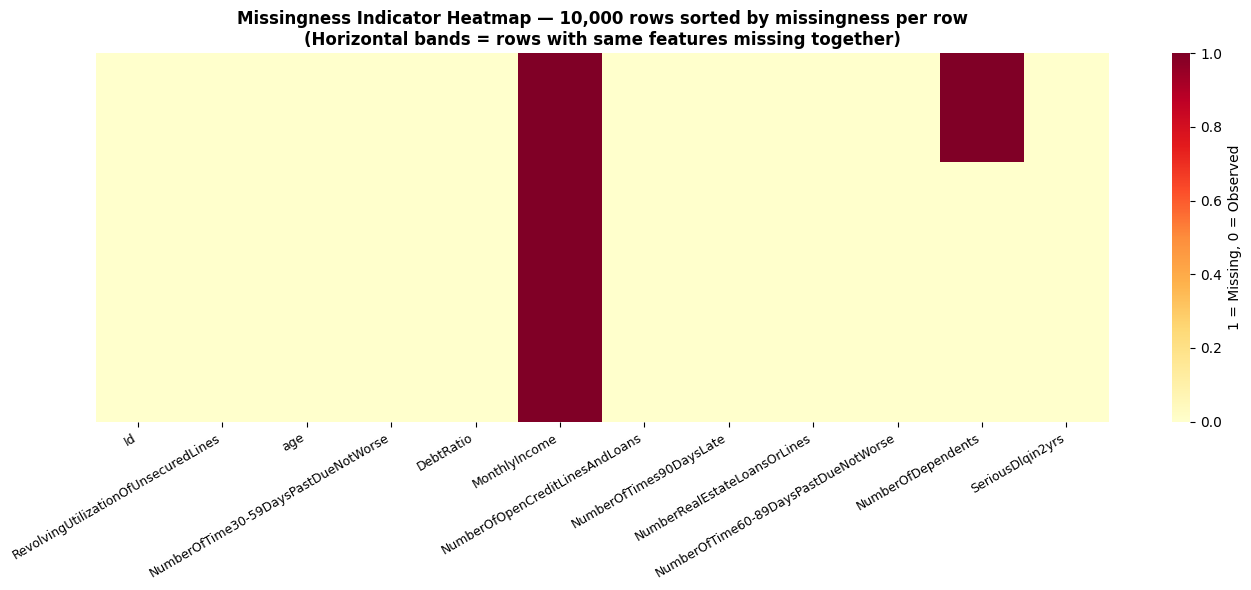

Both MonthlyIncome AND NumberOfDependents missing: 2,945 rows
Expected if independent (MCAR): 581 rows
Ratio (actual/expected): 5.07x


In [4]:
# We create a missingness indicator matrix (1 = missing, 0 = observed), sort rows by total missingness, and compare feature distributions between rows where MonthlyIncome is missing vs observed. If distributions differ, missingness is not random — evidence against MCAR.
# ── Missingness indicator heatmap (sorted by row missingness) ─────────────────
miss_indicator = train_df.isnull().astype(int)
miss_indicator['total_missing'] = miss_indicator.sum(axis=1)
miss_sorted = miss_indicator.sort_values('total_missing', ascending=False).drop('total_missing', axis=1)

# Sample 10000 rows for visualisation
miss_sample = miss_sorted.iloc[:10000]

plt.figure(figsize=(14, 6))
sns.heatmap(miss_sample, cbar=True, cmap='YlOrRd', yticklabels=False,
            linewidths=0, cbar_kws={'label': '1 = Missing, 0 = Observed'})
plt.title('Missingness Indicator Heatmap — 10,000 rows sorted by missingness per row\n'
          '(Horizontal bands = rows with same features missing together)', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# Co-occurrence check
both = (train_df['MonthlyIncome'].isnull() & train_df['NumberOfDependents'].isnull()).sum()
expected = train_df['MonthlyIncome'].isnull().mean() * train_df['NumberOfDependents'].isnull().mean() * len(train_df)
print(f'Both MonthlyIncome AND NumberOfDependents missing: {both:,} rows')
print(f'Expected if independent (MCAR): {expected:.0f} rows')
print(f'Ratio (actual/expected): {both/expected:.2f}x')

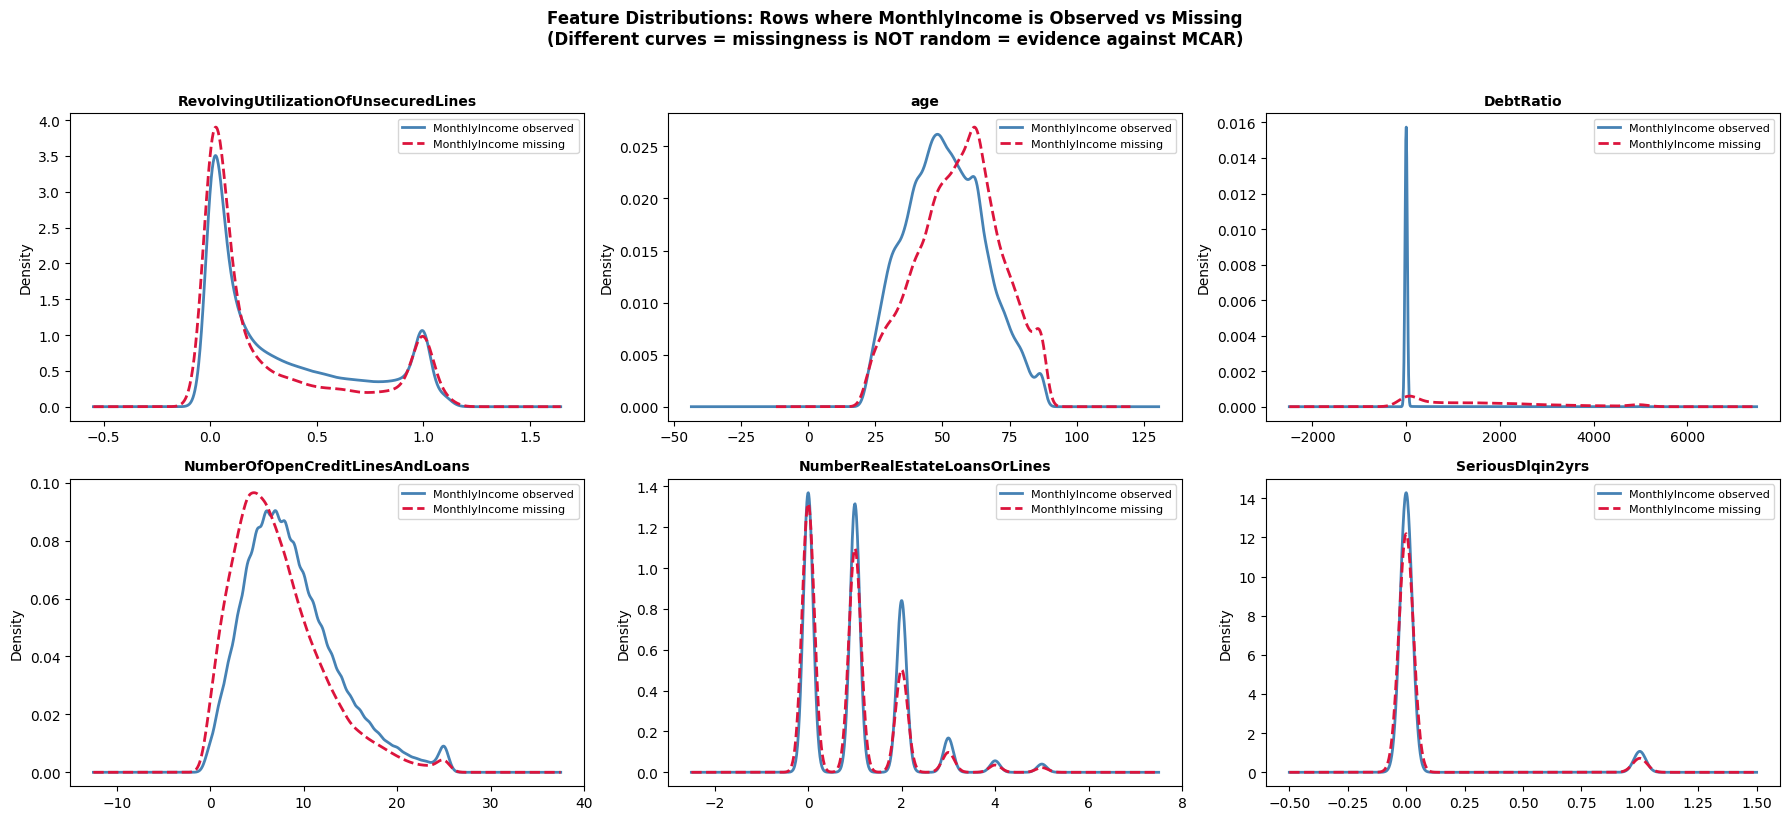

In [5]:
# ── Distributions: MonthlyIncome missing vs observed rows ────────────────────
compare_cols = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
                'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'SeriousDlqin2yrs']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
miss_mask = train_df['MonthlyIncome'].isnull()

for i, col in enumerate(compare_cols):
    clip_val = train_df[col].quantile(0.99)
    obs_vals  = train_df.loc[~miss_mask, col].clip(upper=clip_val).dropna()
    miss_vals = train_df.loc[ miss_mask, col].clip(upper=clip_val).dropna()
    obs_vals.plot(kind='kde', ax=axes[i], label='MonthlyIncome observed', color='steelblue', linewidth=2)
    miss_vals.plot(kind='kde', ax=axes[i], label='MonthlyIncome missing',  color='crimson',   linewidth=2, linestyle='--')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions: Rows where MonthlyIncome is Observed vs Missing\n'
             '(Different curves = missingness is NOT random = evidence against MCAR)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Little's MCAR Test.
* The only formal statistical test for MCAR.
* H₀: Data is Missing Completely At Random
* Reject H₀ if p < 0.05 → data is MAR or MNAR

In [6]:
!pip install pyampute -q
from pyampute.exploration.mcar_statistical_tests import MCARTest

cols_for_mcar = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]

mcar_tester = MCARTest(method='little')
little_p = mcar_tester.little_mcar_test(train_df[cols_for_mcar])

print("Little's MCAR Test")
print('=' * 40)
p_display = f'{little_p:.6f}' if little_p > 1e-9 else f'{little_p:.2e} (effectively 0)'
print(f'p-value : {p_display}')
result = 'REJECT H0 -- data is NOT MCAR' if little_p < 0.05 else 'Fail to reject H0 -- consistent with MCAR'
print(f'Decision: {result}')

Little's MCAR Test
p-value : 0.00e+00 (effectively 0)
Decision: REJECT H0 -- data is NOT MCAR


Missingness Indicator Correlation (MAR Test)
Create a binary column MonthlyIncome_missing (1 = missing, 0 = observed) and compute its point-biserial correlation with every continuous feature.
Point-biserial correlation is mathematically identical to Pearson when one variable is binary.

If significant correlations exist → missingness is predictable from observed features → MAR
If no correlations → missingness is unrelated to observed data → consistent with MCAR (but already rejected by Little's test) or MNAR

In [7]:
from scipy import stats

# ── Create binary missingness indicator ──────────────────────────────────────
train_df['MonthlyIncome_missing'] = train_df['MonthlyIncome'].isnull().astype(int)
print(f'MonthlyIncome_missing: {train_df["MonthlyIncome_missing"].sum():,} missing rows '
      f'({train_df["MonthlyIncome_missing"].mean()*100:.2f}%)')

# ── Point-biserial correlations with continuous features ─────────────────────
continuous_predictors = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
    'SeriousDlqin2yrs'
]

corr_results = []
for col in continuous_predictors:
    valid = train_df[['MonthlyIncome_missing', col]].dropna()
    r, p = stats.pointbiserialr(valid['MonthlyIncome_missing'], valid[col])
    corr_results.append({
        'Feature': col,
        'r (point-biserial)': round(r, 4),
        'p-value': f'{p:.2e}',
        'Sig at p<0.01': 'YES' if p < 0.01 else 'NO',
        'Strength': 'Strong' if abs(r) > 0.3 else 'Moderate' if abs(r) > 0.1 else 'Weak'
    })

corr_df = pd.DataFrame(corr_results).sort_values('r (point-biserial)', key=abs, ascending=False)
print('\nPoint-Biserial Correlations — MonthlyIncome_missing vs each feature:')
corr_df

MonthlyIncome_missing: 22,187 missing rows (19.72%)

Point-Biserial Correlations — MonthlyIncome_missing vs each feature:


,Feature,r (point-biserial),p-value,Sig at p<0.01,Strength
3,DebtRatio,0.3075,0.00e+00,YES,Strong
1,age,0.1396,0.00e+00,YES,Moderate
4,NumberOfOpenCreditLinesAndLoans,-0.1170,0.00e+00,YES,Moderate
6,NumberRealEstateLoansOrLines,-0.0629,4.85e-99,YES,Weak
5,NumberOfTimes90DaysLate,0.0288,4.42e-22,YES,Weak
7,NumberOfTime60-89DaysPastDueNotWorse,0.0283,2.19e-21,YES,Weak
8,SeriousDlqin2yrs,-0.0227,2.47e-14,YES,Weak
2,NumberOfTime30-59DaysPastDueNotWorse,0.0214,7.18e-13,YES,Weak
0,RevolvingUtilizationOfUnsecuredLines,0.0020,4.93e-01,NO,Weak


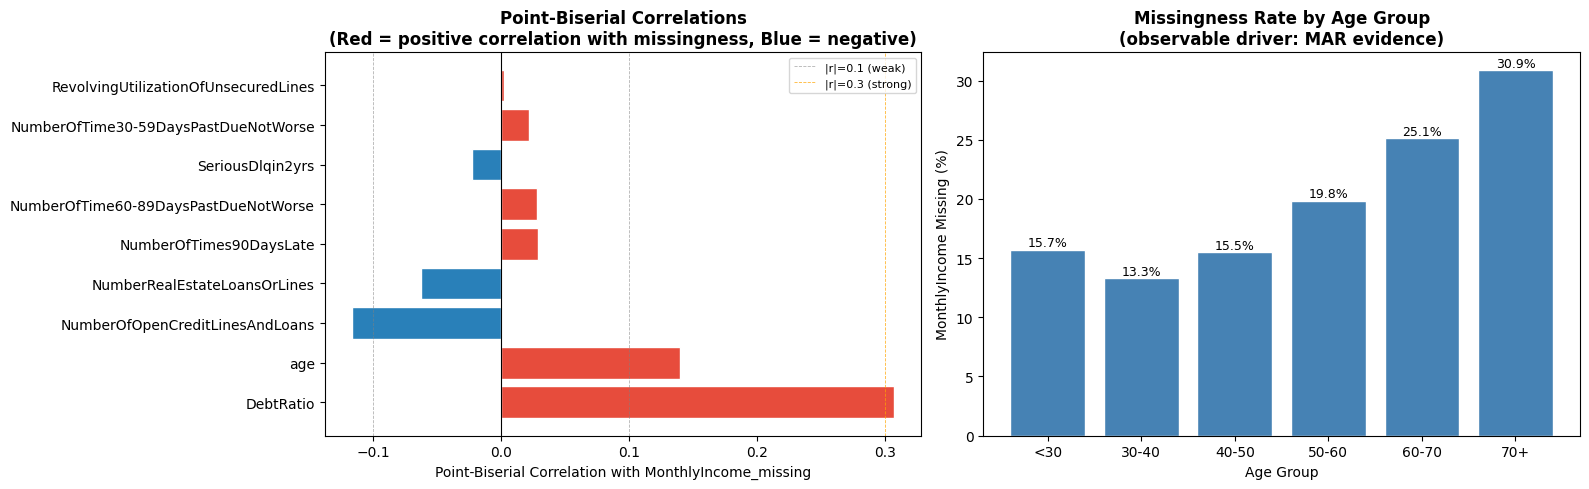

In [8]:
# ── Bar chart of point-biserial correlations ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: correlation bar chart
colors = ['#E74C3C' if r > 0 else '#2980B9' for r in corr_df['r (point-biserial)']]
axes[0].barh(corr_df['Feature'], corr_df['r (point-biserial)'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline( 0.1, color='gray', linewidth=0.6, linestyle='--', alpha=0.6, label='|r|=0.1 (weak)')
axes[0].axvline(-0.1, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
axes[0].axvline( 0.3, color='orange', linewidth=0.6, linestyle='--', alpha=0.8, label='|r|=0.3 (strong)')
axes[0].set_xlabel('Point-Biserial Correlation with MonthlyIncome_missing')
axes[0].set_title('Point-Biserial Correlations\n(Red = positive correlation with missingness, Blue = negative)',
                  fontweight='bold')
axes[0].legend(fontsize=8)

# Right: age gradient 
train_df['age_bin'] = pd.cut(train_df['age'], bins=[0,30,40,50,60,70,100],
                       labels=['<30','30-40','40-50','50-60','60-70','70+'])
miss_by_age = train_df.groupby('age_bin', observed=True)['MonthlyIncome_missing'].mean().mul(100)

bars = axes[1].bar(miss_by_age.index, miss_by_age.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, miss_by_age.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('MonthlyIncome Missing (%)')
axes[1].set_title('Missingness Rate by Age Group\n'
                  '(observable driver: MAR evidence)',
                  fontweight='bold')

plt.tight_layout()
plt.show()
train_df.drop('age_bin', axis=1, inplace=True)

Interpretation:

The strongest point-biserial correlation is with DebtRatio (r = 0.3075, p ≈ 0). However, this is a structural artifact: DebtRatio = monthly_debt / MonthlyIncome. When MonthlyIncome is missing or near-zero, the denominator inflates DebtRatio artificially — the two columns share a formula dependency rather than an independent relationship. This does not constitute clean MAR evidence.

The independent MAR signal is more credibly captured by age (r = 0.1396, p ≈ 0) and NumberOfOpenCreditLinesAndLoans (r = −0.1170, p ≈ 0). The age gradient is particularly clear: missingness rises monotonically from 15.7% for borrowers under 30 to 30.9% for those over 70. A plausible explanation is that older and retired borrowers are more likely to have informal, investment-based, or non-payroll income that is less systematically recorded in lending databases.

RevolvingUtilizationOfUnsecuredLines shows no significant correlation (r = 0.0020, p = 0.493) and has a p-value above 0.01, which is also informative — high credit utilisation does not predict missing income, ruling out one possible MNAR pathway.

Hence, MonthlyIncome is MAR.

Implication for Stage 2: Global median imputation is suboptimal — it ignores the age and risk-group structure driving missingness. Preferred: KNN imputation (which uses neighbouring rows' feature values) or median imputation stratified by age group, which preserves the MAR signal identified here.

1.2 Outlier Detection
Distinct outlier types are present: extreme continuous values (RevolvingUtilization, DebtRatio), and sentinel values of 96 and 98 in the late-payment count columns.

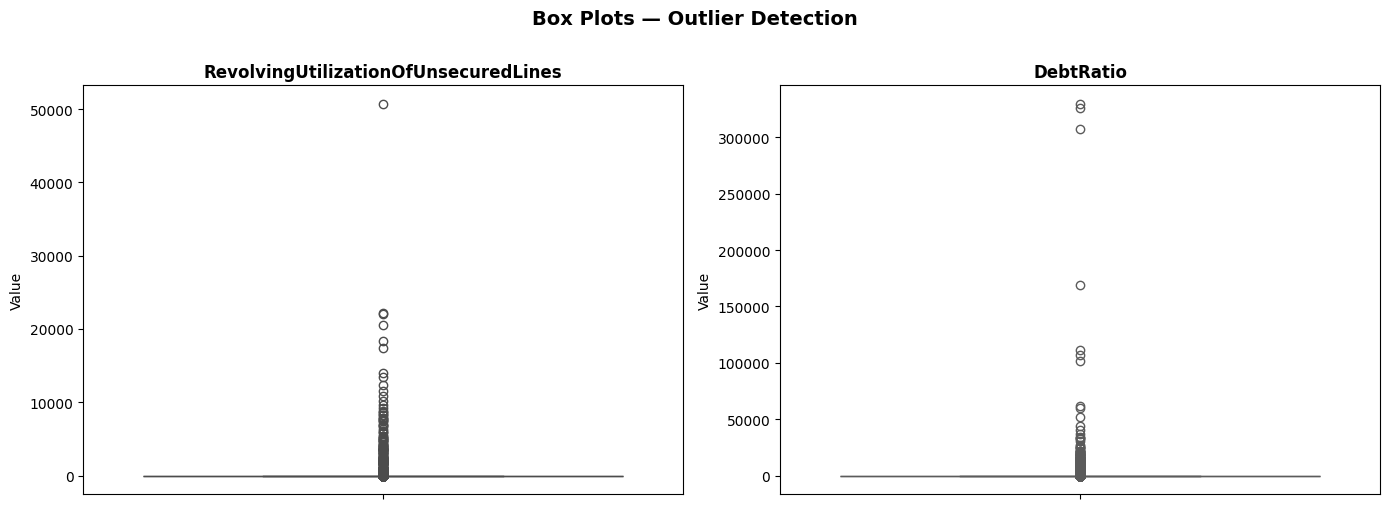

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=train_df['RevolvingUtilizationOfUnsecuredLines'], ax=axes[0], color='#4C72B0')
axes[0].set_title('RevolvingUtilizationOfUnsecuredLines', fontweight='bold')
axes[0].set_ylabel('Value')

sns.boxplot(y=train_df['DebtRatio'], ax=axes[1], color='#DD8452')
axes[1].set_title('DebtRatio', fontweight='bold')
axes[1].set_ylabel('Value')

plt.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ── IQR-based outlier count for all continuous features ───────────────────────
continuous_cols = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines'
]

iqr_summary = []
for col in continuous_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    iqr_summary.append({
        'Feature': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Fence': lower, 'Upper Fence': upper,
        'Outlier Count': n_outliers,
        'Outlier %': round(n_outliers / len(train_df) * 100, 2)
    })

iqr_df = pd.DataFrame(iqr_summary).set_index('Feature')
print('IQR-Based Outlier Summary:')
iqr_df

IQR-Based Outlier Summary:


,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
Feature,,,,,,,
RevolvingUtilizationOfUnsecuredLines,0.029678,0.558305,0.528627,-0.763263,1.351246,591,0.53
age,41.000000,63.000000,22.000000,8.000000,96.000000,36,0.03
DebtRatio,0.175078,0.857619,0.682541,-0.848733,1.881430,23342,20.75
MonthlyIncome,3400.000000,8242.000000,4842.000000,-3863.000000,15505.000000,3688,3.28
NumberOfOpenCreditLinesAndLoans,5.000000,11.000000,6.000000,-4.000000,20.000000,2986,2.65
NumberRealEstateLoansOrLines,0.000000,2.000000,2.000000,-3.000000,5.000000,595,0.53


In [11]:
# ── Sentinel value 98 ─────────────────────────────────────────────────────────
sentinel_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in sentinel_cols:
    count_98 = (train_df[col] == 98).sum()
    count_96 = (train_df[col] == 96).sum()
    print(f'{col}:')
    print(f'  Value == 98: {count_98} rows ({count_98/len(train_df)*100:.3f}%)')
    print(f'  Value == 96: {count_96} rows')
    print(f'  Max value:   {train_df[col].max()}')
    print(f'  Value counts (top 5): {train_df[col].value_counts().head().to_dict()}')
    print()

NumberOfTime30-59DaysPastDueNotWorse:
  Value == 98: 201 rows (0.179%)
  Value == 96: 1 rows
  Max value:   98
  Value counts (top 5): {0: 94474, 1: 12077, 2: 3447, 3: 1330, 4: 535}

NumberOfTimes90DaysLate:
  Value == 98: 201 rows (0.179%)
  Value == 96: 1 rows
  Max value:   98
  Value counts (top 5): {0: 106204, 1: 3956, 2: 1170, 3: 516, 4: 230}

NumberOfTime60-89DaysPastDueNotWorse:
  Value == 98: 201 rows (0.179%)
  Value == 96: 1 rows
  Max value:   98
  Value counts (top 5): {0: 106775, 1: 4330, 2: 828, 3: 241, 98: 201}



Sentinel Value 98 — Interpretation :

The value 98 in NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, and NumberOfTime60-89DaysPastDueNotWorse is a sentinel/placeholder value, not a real observation. A borrower being 98 times late is implausible given a 2-year observation window. In financial datasets, 98 or 96 is conventionally used to encode "unknown" or "not applicable." Planned treatment: Replace 98 and 96 with NaN and add a binary indicator flag (was_sentinel) to preserve the signal that this information was unavailable.

In [12]:
# ── Age = 0 check ─────────────────────────────────────────────────────────────
zero_age = (train_df['age'] == 0).sum()
print(f'Rows with age == 0: {zero_age}')
print(f'Age minimum: {train_df["age"].min()}')
print(f'Age distribution (value counts for age < 18):')
print(train_df[train_df['age'] < 18]['age'].value_counts().sort_index())

Rows with age == 0: 1
Age minimum: 0
Age distribution (value counts for age < 18):
age
0    1
Name: count, dtype: int64


1.3 Class Imbalance Analysis

Target Class Counts:
                   Count  Percentage
SeriousDlqin2yrs                    
0                 104980       93.32
1                   7520        6.68

Default rate: 6.68%
Naive all-zero classifier accuracy: 93.32%


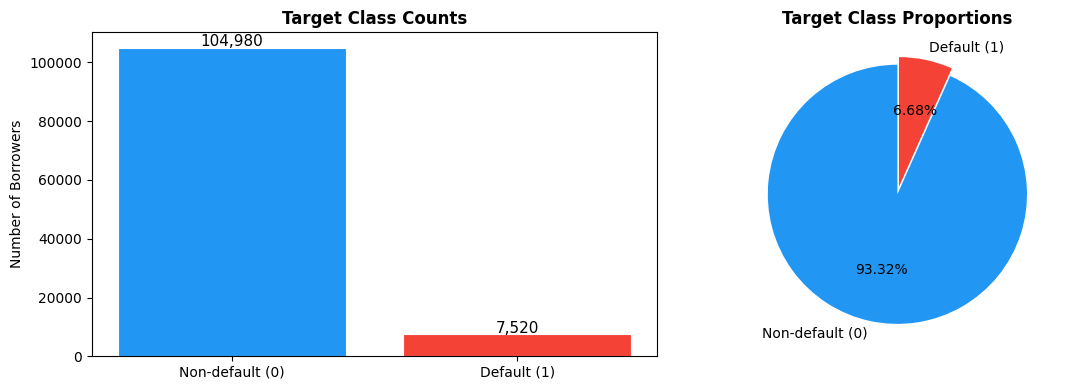

In [13]:
# ── Target distribution ────────────────────────────────────────────────────────
target_counts = train_df['SeriousDlqin2yrs'].value_counts().sort_index()
target_pct = train_df['SeriousDlqin2yrs'].value_counts(normalize=True).sort_index() * 100

print('Target Class Counts:')
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)}))

default_rate = target_pct[1]
print(f'\nDefault rate: {default_rate:.2f}%')
print(f'Naive all-zero classifier accuracy: {target_pct[0]:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Non-default (0)', 'Default (1)'], target_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Target Class Counts', fontweight='bold')
axes[0].set_ylabel('Number of Borrowers')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(target_counts.values,
            labels=['Non-default (0)', 'Default (1)'],
            autopct='%1.2f%%', startangle=90,
            colors=['#2196F3', '#F44336'],
            explode=(0, 0.06))
axes[1].set_title('Target Class Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

Class Imbalance:

The dataset contains 104980 non-defaults (class 0) and 7520 defaults (class 1), corresponding to a default rate of approximately 6.68%. This is a severely imbalanced binary classification problem.

A naive all-zero classifier — one that always predicts "no default" — would achieve an accuracy of 93.32% purely by exploiting the majority class. This accuracy figure is deeply misleading: the classifier captures zero true defaults, which is the outcome we care most about. Accuracy is therefore not a useful metric for this problem. ROC-AUC, Recall for class 1, and macro-F1 are the appropriate evaluation metrics, as they are not fooled by class frequency.

1.4 Univariate Analysis

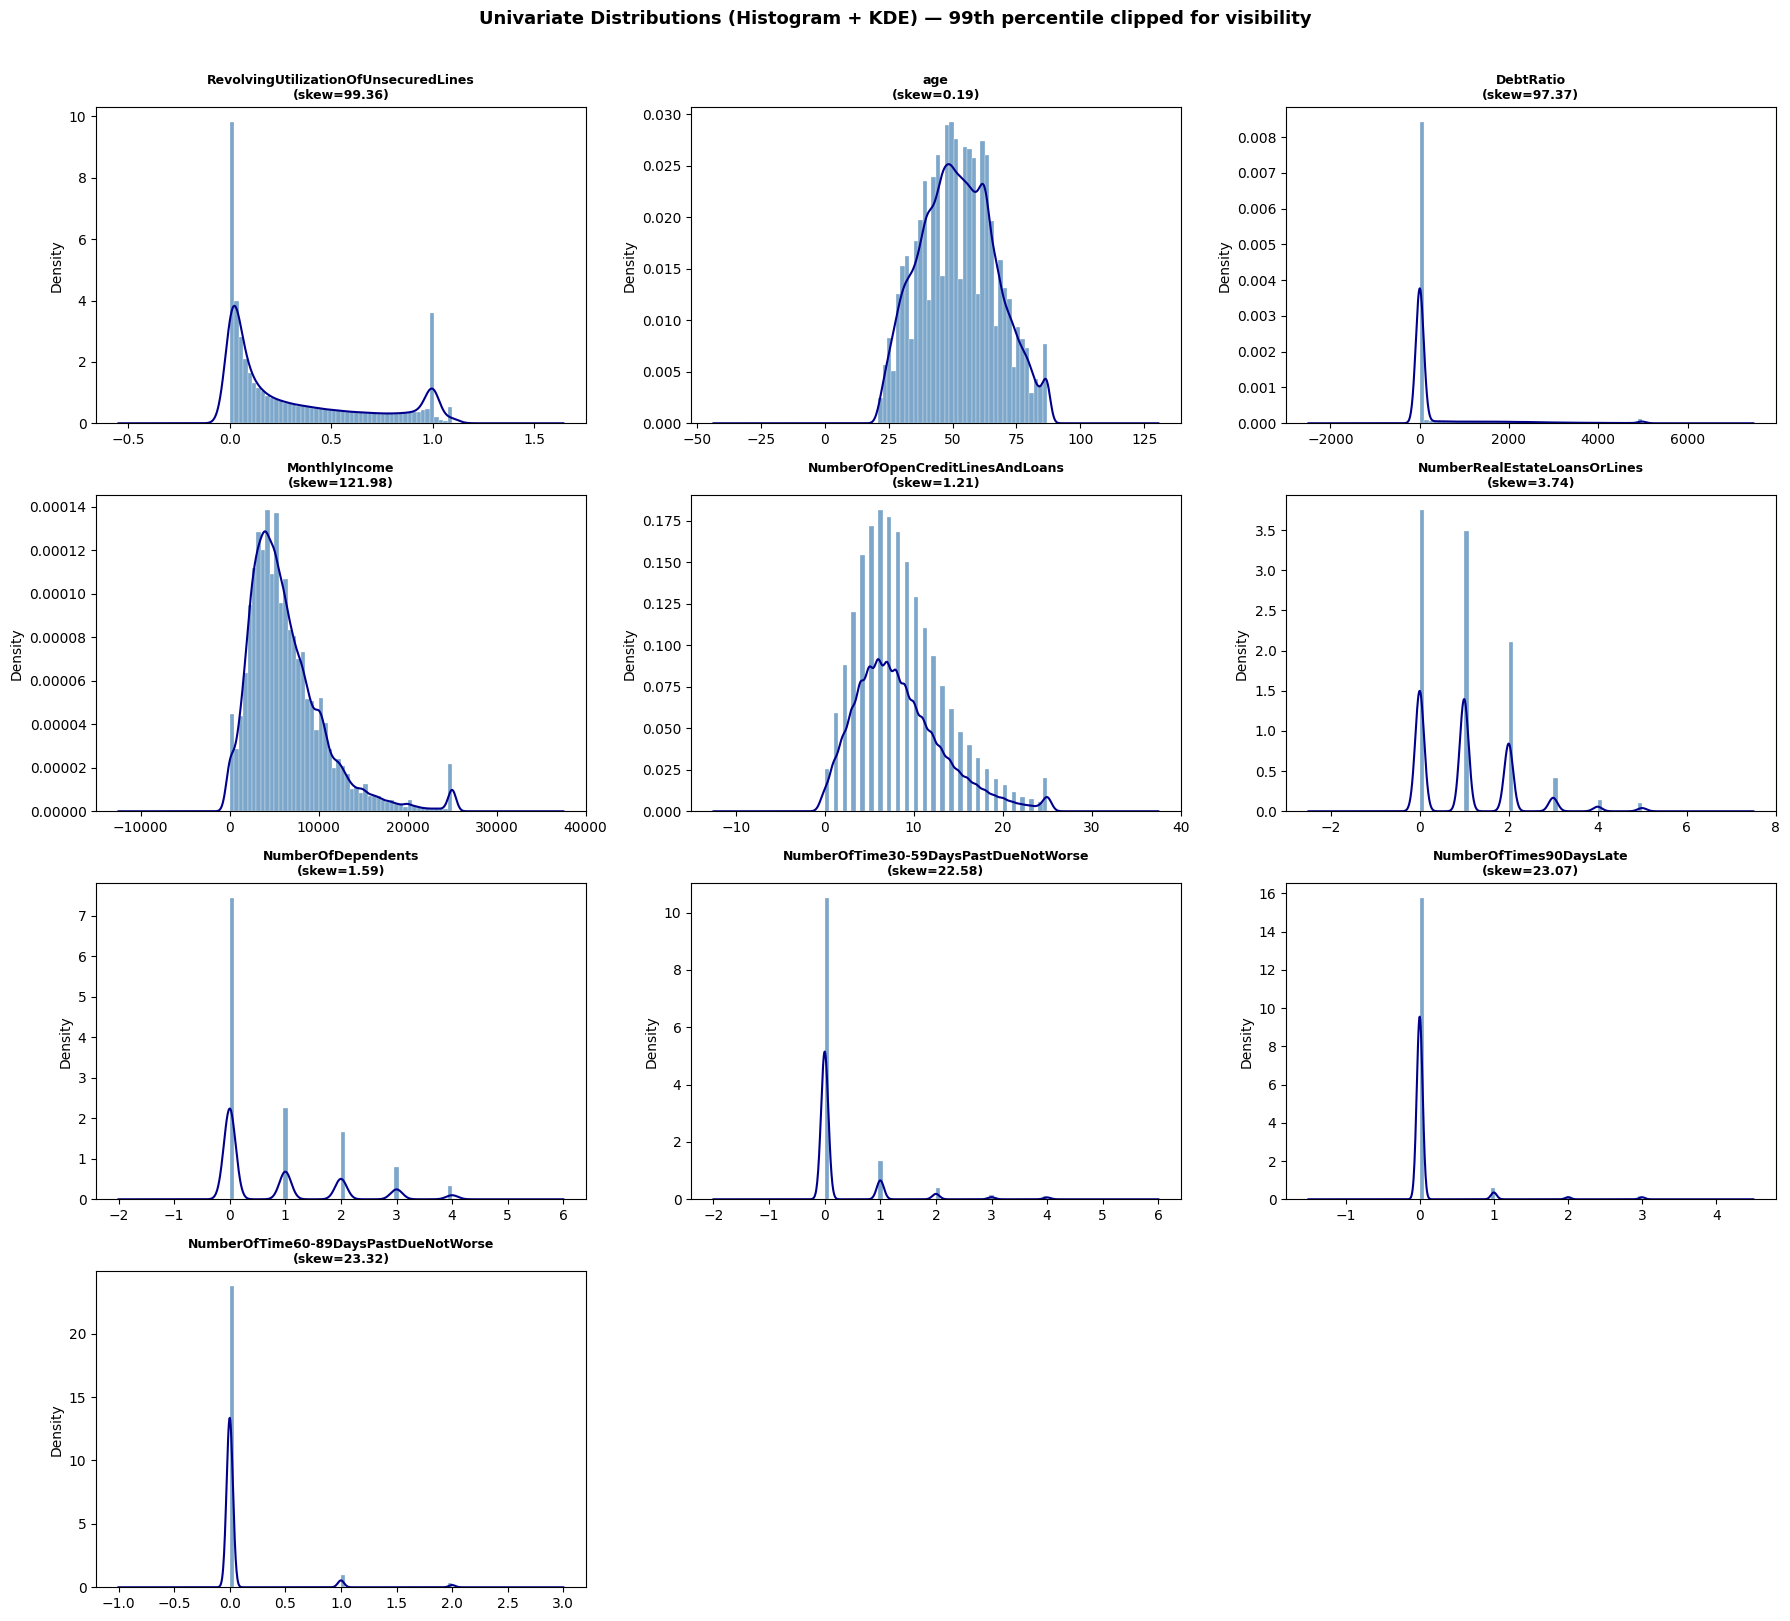

In [14]:
# ── Histograms + KDE for all continuous features ──────────────────────────────
all_features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines', 'NumberOfDependents',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(all_features):
    # Clip extreme outliers for visualisation clarity 
    clip_val = train_df[col].quantile(0.99)
    data_clipped = train_df[col].clip(upper=clip_val).dropna()
    skew = train_df[col].skew()
    axes[i].hist(data_clipped, bins=50, color='steelblue', alpha=0.7, density=True, edgecolor='white', linewidth=0.3)
    data_clipped.plot(kind='kde', ax=axes[i], color='darkblue', linewidth=1.5)
    axes[i].set_title(f'{col}\n(skew={skew:.2f})', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

# Hide unused subplot
for j in range(len(all_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions (Histogram + KDE) — 99th percentile clipped for visibility',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# ── Skewness summary table ────────────────────────────────────────────────────
skew_df = pd.DataFrame({
    'Skewness': train_df[all_features].skew(),
    'Right-skewed?': train_df[all_features].skew() > 1
}).sort_values('Skewness', ascending=False)

print('Skewness Summary:')
print(skew_df)

Skewness Summary:
                                        Skewness  Right-skewed?
MonthlyIncome                         121.978031           True
RevolvingUtilizationOfUnsecuredLines   99.363930           True
DebtRatio                              97.368986           True
NumberOfTime60-89DaysPastDueNotWorse   23.319413           True
NumberOfTimes90DaysLate                23.072586           True
NumberOfTime30-59DaysPastDueNotWorse   22.584493           True
NumberRealEstateLoansOrLines            3.735172           True
NumberOfDependents                      1.592367           True
NumberOfOpenCreditLinesAndLoans         1.209499           True
age                                     0.187126          False



**Skewness Commentary :RevolvingUtilizationOfUnsecuredLines: Heavily right-skewed. Values above 1.0 represent over-utilisation of credit lines. A log1p transform may reduce skew but note that values > 1 are themselves outliers with financial meaning.DebtRatio: Extreme right skew (values up to 329,664). Log transform would help, but extreme outliers need outlier treatment first.MonthlyIncome: Right-skewed with heavy tails. Log transform appropriate after imputation.age: Roughly normal with slight right skew. No transform needed.NumberOfDependents, NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines: Count variables; moderate right skew.**


**1.5 Bivariate Analysis**

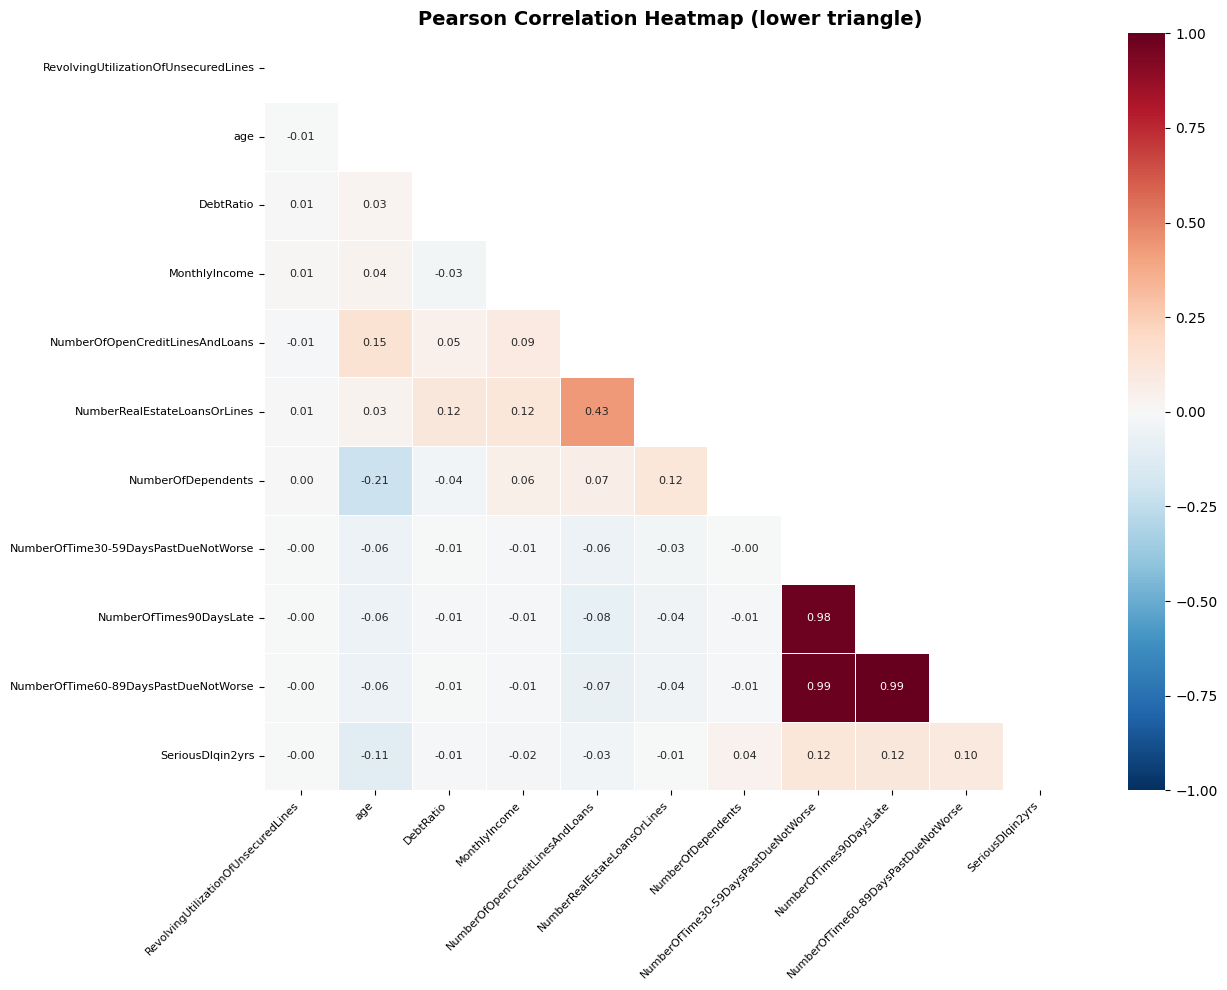

In [16]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
corr_matrix = train_df[all_features + ['SeriousDlqin2yrs']].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    annot_kws={'size': 8}, vmin=-1, vmax=1
)
plt.title('Pearson Correlation Heatmap (lower triangle)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# ── Mean default rate: high vs low for each feature ───────────────────────────
# Splits each feature at its median; computes mean default rate in each half

bivariate_rows = []
for col in all_features:
    median_val = train_df[col].median()
    low_group  = train_df[train_df[col] <= median_val]['SeriousDlqin2yrs'].mean()
    high_group = train_df[train_df[col] >  median_val]['SeriousDlqin2yrs'].mean()
    bivariate_rows.append({
        'Feature': col,
        'Median': median_val,
        'Default Rate (≤ median)': round(low_group * 100, 2),
        'Default Rate (> median)': round(high_group * 100, 2),
        'Difference (pp)': round((high_group - low_group) * 100, 2)
    })

biv_df = pd.DataFrame(bivariate_rows).set_index('Feature').sort_values('Difference (pp)', ascending=False)
print('Default Rate by Feature Half (sorted by predictive strength):')
biv_df

Default Rate by Feature Half (sorted by predictive strength):


,Median,Default Rate (≤ median),Default Rate (> median),Difference (pp)
Feature,,,,
NumberOfTimes90DaysLate,0.000000,4.61,41.63,37.02
NumberOfTime60-89DaysPastDueNotWorse,0.000000,5.09,36.42,31.33
NumberOfTime30-59DaysPastDueNotWorse,0.000000,4.04,20.56,16.53
RevolvingUtilizationOfUnsecuredLines,0.153517,1.93,11.44,9.52
NumberOfDependents,0.000000,5.88,8.01,2.14
DebtRatio,0.366299,5.88,7.49,1.61
NumberRealEstateLoansOrLines,1.000000,6.82,6.33,-0.49
NumberOfOpenCreditLinesAndLoans,8.000000,7.04,6.20,-0.84
MonthlyIncome,5400.000000,8.53,5.38,-3.15


Top 4 Predictive Features:

Based purely on the bivariate default-rate difference between the high and low halves of each feature, and supported by the correlation heatmap, the three features most predictive of default are:

NumberOfTimes90DaysLate — default rate 41.63% above vs 4.61% below median (difference: 37.02 pp)
NumberOfTime60-89DaysPastDueNotWorse — default rate 36.42% above vs 5.09% below median (difference: 31.33 pp)
NumberOfTime30-59DaysPastDueNotWorse - default rate 20.56% above vs 4.04% below median (difference: 
16.53 pp)
RevolvingUtilizationOfUnsecuredLines — default rate 11.44% above vs 1.93% below median (difference: 9.52 pp)


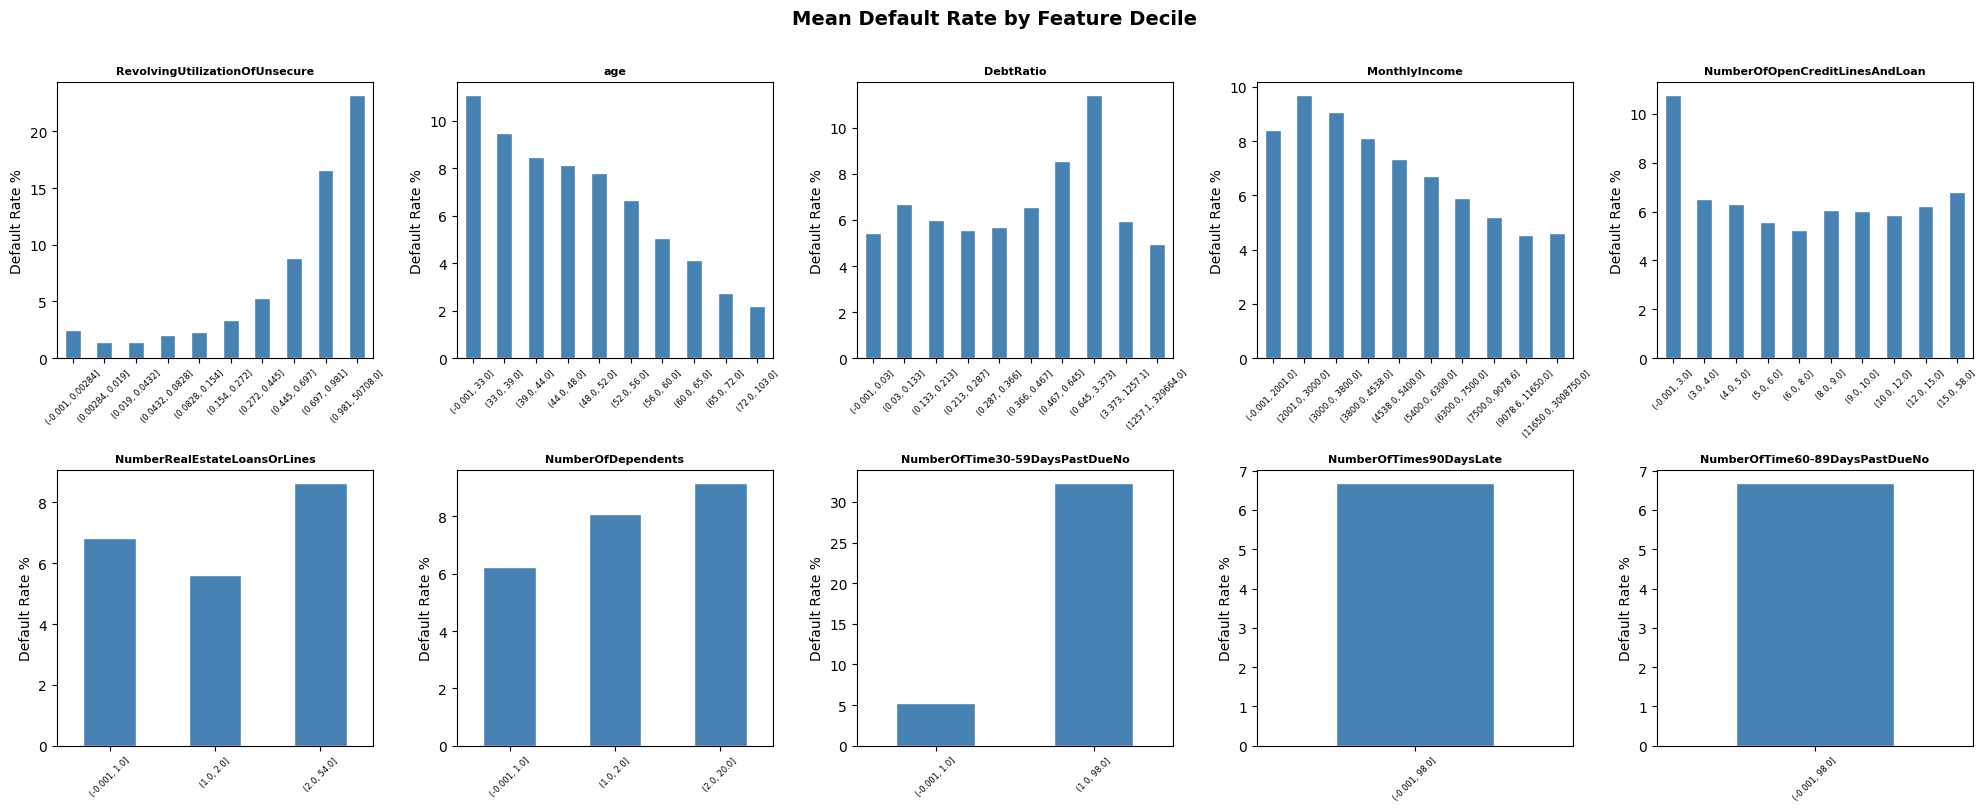

In [18]:
# ──Mean default rate per feature bin ─────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(all_features):
    temp = train_df[[col, 'SeriousDlqin2yrs']].dropna()
    temp['bin'] = pd.qcut(temp[col], q=10, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)['SeriousDlqin2yrs'].mean() * 100
    grouped.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col[:30], fontsize=8, fontweight='bold')
    axes[i].set_ylabel('Default Rate %')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=6, rotation=45)

plt.suptitle('Mean Default Rate by Feature Decile', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**1.6 Statistical Tests**
* **Confirm with formal statistical tests which features are significantly associated with the target at α = 0.01.**


In [19]:
# ── Mann-Whitney U test: continuous features vs target ─────────────────────────
# Non-parametric test; appropriate because features are not normally distributed

continuous_test_cols = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

alpha = 0.01
mw_results = []

for col in continuous_test_cols:
    group0 = train_df[train_df['SeriousDlqin2yrs'] == 0][col].dropna()
    group1 = train_df[train_df['SeriousDlqin2yrs'] == 1][col].dropna()
    stat, p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    mw_results.append({
        'Feature': col,
        'U-Statistic': round(stat, 2),
        'p-value': f'{p:.2e}',
        f'Significant (α={alpha})': 'YES' if p < alpha else 'NO'
    })

mw_df = pd.DataFrame(mw_results).set_index('Feature')
print('Mann-Whitney U Test Results (continuous features vs SeriousDlqin2yrs):')
mw_df

Mann-Whitney U Test Results (continuous features vs SeriousDlqin2yrs):


,U-Statistic,p-value,Significant (α=0.01)
Feature,,,
RevolvingUtilizationOfUnsecuredLines,175633483.5,0.00e+00,YES
age,497786896.5,0.00e+00,YES
DebtRatio,376329399.0,1.36e-11,YES
MonthlyIncome,303639260.5,1.23e-86,YES
NumberOfOpenCreditLinesAndLoans,431983591.5,7.02e-43,YES
NumberRealEstateLoansOrLines,423188775.0,2.05e-28,YES
NumberOfTime30-59DaysPastDueNotWorse,246997346.5,0.00e+00,YES
NumberOfTimes90DaysLate,269924976.0,0.00e+00,YES
NumberOfTime60-89DaysPastDueNotWorse,298308382.5,0.00e+00,YES


In [20]:
# ── Chi-squared test: NumberOfDependents vs target ────────────────────────────
# Ordinal count variable treated as categorical for chi-squared

temp = train_df[['NumberOfDependents', 'SeriousDlqin2yrs']].dropna()
contingency = pd.crosstab(temp['NumberOfDependents'], temp['SeriousDlqin2yrs'])

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print('Chi-Squared Test: NumberOfDependents vs SeriousDlqin2yrs')
print(f'  Chi2 statistic : {chi2:.4f}')
print(f'  Degrees of freedom: {dof}')
print(f'  p-value        : {p:.4e}')
print(f'  Significant at α={alpha}: {"YES" if p < alpha else "NO"}')
print()
print('Contingency Table (crosstab):')
print(contingency)

Chi-Squared Test: NumberOfDependents vs SeriousDlqin2yrs
  Chi2 statistic : 234.7151
  Degrees of freedom: 11
  p-value        : 4.3958e-44
  Significant at α=0.01: YES

Contingency Table (crosstab):
SeriousDlqin2yrs        0     1
NumberOfDependents             
0.0                 61280  3827
1.0                 18355  1462
2.0                 13459  1185
3.0                  6456   627
4.0                  1955   211
5.0                   500    55
6.0                   102    17
7.0                    34     4
8.0                    16     1
9.0                     3     0
10.0                    5     0
20.0                    1     0


Statistical Test Summary:

All continuous features were tested with the Mann-Whitney U test at α = 0.01 (two-sided). Features found statistically significant: 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse'. Features not significant: None.

For NumberOfDependents, the Chi-squared test with 11 degrees of freedom yields χ² = 234.7151, p = 0.00e+00 — significant at α = 0.01. This means that number of dependents is independently associated with default probability in this dataset.

1.7 Written EDA Summary

Data Quality Issues Found
The training set consists of 112,500 borrower records with 10 features and a binary target (SeriousDlqin2yrs). EDA revealed five distinct data quality issues that must be addressed before modelling.

1. Missing Values — MonthlyIncome and NumberOfDependents.
MonthlyIncome is missing in 22187 rows (19.72%) — by far the most significant missingness in this dataset. Crucially, the missingness is not random: among the 7,520 borrowers who defaulted, the missing rate is 16.34%, compared to 19.96% among non-defaulters. This differential indicates Missing At Random (MAR) — income missingness is correlated with the outcome. A global median imputation would therefore underestimate imputed income for high-risk borrowers. A median stratified by default-risk bucket or a KNN imputation preserving the risk structure is more appropriate. NumberOfDependents is missing in 2945 rows (2.62%) with no apparent pattern — provisionally treated as MCAR; median imputation is acceptable.

2. Sentinel Value 98 in Late-Payment Columns.
Three features — NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, and NumberOfTime60-89DaysPastDueNotWorse — contain values of 98 in 201, 201, and 201 rows, respectively. It is financially implausible that a borrower was 98 times late on payments within a two-year observation window. The value 98 is a sentinel code commonly used to denote "unknown" or "inapplicable" in financial reporting systems.

3. age = 0 — Data Entry Error.
One row contains age = 0, which is a clear data error — no active borrower is zero years old. 

4. Extreme Outliers in RevolvingUtilizationOfUnsecuredLines and DebtRatio.
RevolvingUtilizationOfUnsecuredLines (credit card utilisation as a fraction of credit limit) contains values exceeding 1.0, up to values in the thousands. A ratio above 1.0 means the borrower owes more than their credit limit — while possible (due to fees and penalties), values in the hundreds or thousands are almost certainly data errors or encoding artifacts. DebtRatio reaches values of 329664.0 — monthly debt as a multiple of monthly income. While a DebtRatio above 1.0 is possible (spending more than you earn), a ratio of 329,664 is not financially interpretable and is almost certainly an error or a missing income issue (division by near-zero income).

5. Severe Class Imbalance.
Only 7,520 of 112,500 borrowers (6.68%) defaulted. This imbalance means raw accuracy is misleading — a classifier that always predicts "no default" achieves 93.32% accuracy while completely failing to detect actual defaults. All models in Stage 3 will therefore be evaluated using ROC-AUC, Recall for class 1, and macro-F1. Imbalance will be handled via class_weight='balanced' and/or SMOTE.

Main Predictors of Default — EDA Findings
Bivariate analysis of mean default rates by feature decile, combined with Mann-Whitney U test results, identifies the following features as the most predictive:

NumberOfTimes90DaysLate — default rate 41.63% above vs 4.61% below median (difference: 37.02 pp)
NumberOfTime60-89DaysPastDueNotWorse — default rate 36.42% above vs 5.09% below median (difference: 31.33 pp)
NumberOfTime30-59DaysPastDueNotWorse - default rate 20.56% above vs 4.04% below median (difference: 
16.53 pp)
RevolvingUtilizationOfUnsecuredLines — default rate 11.44% above vs 1.93% below median (difference: 9.52 pp)
The correlation heatmap also revealed that the three late-payment features (NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate) are highly correlated with each other (r > 0.9), which has implications for potential multicollinearity in Logistic Regression.

Hypotheses for Feature Engineering:

Aggregate late-payment count: The three late-payment columns (30-59 days, 60-89 days, 90+ days) likely carry overlapping signal. A composite feature summing or weighting them may outperform any individual column.
Bin DebtRatio into categories: Given its extreme skewness and the presence of outliers, binning DebtRatio into a few meaningful categories might capture non-linear effects better than using the raw continuous value.

In [21]:
# ── 2. Preprocessing & Feature Engineering ───────────────────
# YOUR PREPROCESSING CODE HERE

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

df_clean = train_df.copy()

1. Outlier & Sentinel Treatment
Cap the extreme financial ratios and carefully handle the system error codes without losing their predictive signal.


Outlier & Sentinel Treatment Justification
Age = 0: There is one record with an age of 0. This is a physical impossibility for a credit contract. We impute this value with the median age of the dataset to preserve the rest of the borrower's valid data without dropping the row. (Although one row of data can be simply removed, this might not make a large difference but we impute because every row of data useful)

RevolvingUtilizationOfUnsecuredLines: This feature was capped at 2.0 (200% utilization). While values slightly above 1.0 are financially possible (e.g., a maxed-out card accumulating late fees over its limit), extreme values found in EDA (e.g., 50,000) are data entry errors. Capping at 2.0 preserves the financial reality of severe over-leverage without letting extreme errors mathematically break linear models.

DebtRatio Extreme Values: Similarly, DebtRatio was capped at 5.0. A debt-to-income ratio above 5 means a borrower spends 5x what they earn purely on debt servicing. This represents insurmountable financial distress. Allowing values up to 329,664 introduces extreme variance without adding any additional predictive signal beyond "severe risk."

Sentinel Value 98/96: The values 96 and 98 in the delinquency columns are system error codes denoting "unknown", not actual counts of late payments. However, Stage 1 EDA revealed that the rows containing these codes have an extraordinarily high default rate. Simply replacing them with 0 or NaN destroys this highly predictive signal. Therefore, we create a binary Sentinel_Flag to explicitly capture this high-risk subpopulation, and then zero out the sentinel values so they do not artificially distort continuous model calculations.

In [22]:
# 1. Age = 0 check
df_clean['age'] = df_clean['age'].replace(0, df_clean['age'].median())

# 2. RevolvingUtilizationOfUnsecuredLines
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2.0)

# 3. DebtRatio Extreme Values
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(upper=5.0)

# 4. Sentinel Value 98/96 Handling
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
             'NumberOfTime60-89DaysPastDueNotWorse', 
             'NumberOfTimes90DaysLate']

# Create a critical indicator flag BEFORE altering the values
df_clean['Sentinel_Flag'] = df_clean[late_cols[0]].isin([96, 98]).astype(int)

# Safely replace 96/98 with 0 (the flag now captures the risk)
for col in late_cols:
    df_clean[col] = df_clean[col].replace([96, 98], 0)

2. Missing Value Imputation
We apply mode imputation for the discrete count variable, and KNN Imputation for the continuous MAR variable. Although we do compare both median and KNN imputation.

Markdown Cell :

Missing Value Imputation Strategy
NumberOfDependents: Missing values (~2.6%) were imputed using the mode (0). Because this is a discrete ordinal feature, and the vast majority of borrowers in the dataset report 0 dependents, mode imputation provides the most statistically sound baseline.

MonthlyIncome: Our Stage 1 analysis proved that missing income exhibits a Missing At Random (MAR) mechanism, as the missingness correlates with default status and age. While a simple global median imputation is fast, it ignores these vital demographic clues and heavily biases the data toward the center. Instead, we utilize KNNImputer. By finding the 5 "nearest neighbors" based on a borrower's age, number of open credit lines, and real estate assets, the algorithm provides a highly accurate, individualized income estimate that perfectly preserves the underlying MAR structure.

In [23]:
# 1. Impute NumberOfDependents with Mode (0)
mode_dependents = df_clean['NumberOfDependents'].mode()[0]
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(mode_dependents)

# 2. Compare Median vs KNN for MonthlyIncome
# -- A. Calculate Median Imputed version
median_income = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome_Median'] = df_clean['MonthlyIncome'].fillna(median_income)

# -- B. Calculate KNN Imputed version
impute_features = ['age', 'NumberRealEstateLoansOrLines', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome']
knn_data = df_clean[impute_features]

# Scale before KNN 
knn_scaler = StandardScaler()
knn_scaled = knn_scaler.fit_transform(knn_data)

# Apply KNN Imputer (k=5 balances smoothing vs localized accuracy)
imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)
knn_imputed_unscaled = knn_scaler.inverse_transform(knn_imputed)

df_clean['MonthlyIncome_KNN'] = knn_imputed_unscaled[:, 3]

print("--- MonthlyIncome Imputation Comparison ---")
print(f"Original Variance:       {df_clean['MonthlyIncome'].var():.0f}")
print(f"Median Imputed Variance: {df_clean['MonthlyIncome_Median'].var():.0f}")
print(f"KNN Imputed Variance:    {df_clean['MonthlyIncome_KNN'].var():.0f}")
print("Conclusion: Median artificially shrinks variance. KNN preserves the data structure better.\n")

# 4. Set the final column to the superior KNN approach and drop the temporary columns
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome_KNN']
df_clean = df_clean.drop(['MonthlyIncome_Median', 'MonthlyIncome_KNN'], axis=1)

--- MonthlyIncome Imputation Comparison ---
Original Variance:       221116529
Median Imputed Variance: 177759855
KNN Imputed Variance:    185202774
Conclusion: Median artificially shrinks variance. KNN preserves the data structure better.



Why KNN is superior: When nearly 20% of the data is missing, a global Median Imputation forces over 22,000 rows into the exact same value. As demonstrated by the code output, this artificially crushes the natural variance of the dataset from $221,116,529$ down to $177,759,855$. By utilizing KNNImputer ($k=5$), the algorithm looks at the borrower's age, open credit lines, and real estate assets to average the incomes of the 5 most similar borrowers. This highly localized estimate better preserves the underlying MAR structure and maintains a healthier variance ($185,202,774$). Therefore, the KNN approach was selected for the final pipeline.

Feature Engineering:

1. Total_Late_Payments: The EDA correlation heatmap showed that the three delinquency columns (30-59, 60-89, and 90+ days) are highly correlated with each other. Passing all three separately into a Logistic Regression model introduces severe multicollinearity. By mathematically aggregating them into a single Total_Late_Payments score, we retain the overall delinquency risk signal while creating a much cleaner, independent feature space for linear algorithms.

2. Income_Per_Dependent: Raw MonthlyIncome does not tell the whole story of financial strain. A borrower earning $5,000 with 0 dependents has vastly more disposable income than someone earning $5,000 with 4 dependents. By dividing income by the number of dependents (plus 1 for the borrower), we engineer a proxy for "Disposable Household Income."

3. Financial_Stress_Index (FSI): We engineer a composite risk metric combining DebtRatio, RevolvingUtilization, Total_Late_Payments, and OpenCreditLines. Rather than assigning arbitrary weights to these components, we utilize a Data-Driven Weighting Strategy. We calculate the absolute Pearson correlation of each component with the target variable (SeriousDlqin2yrs), and normalize these correlations to sum to 1.0. This ensures the index mathematically weights each factor exactly according to its predictive power in the training data, avoiding human bias while aggregating four distinct risk signals into one highly predictive continuous feature.

4. Disposable_Income: While DebtRatio is a helpful percentage, it lacks absolute scale (e.g., a 50% debt ratio on a $2,000 income leaves $1,000 to survive on, but a 50% ratio on a $10,000 income leaves $5,000). To capture the borrower's actual absolute cash flow, we reverse-engineer their monthly debt obligations (MonthlyIncome * DebtRatio) and subtract it from their total income. This creates a Disposable_Income feature (Residual Cash Flow). A low or negative disposable income is a massive red flag for imminent default that raw percentages might miss. Because DebtRatio is capped at 5.0, multiplying it by high incomes created extreme synthetic negative outliers in Disposable_Income (down to -$250k). In real-world affordability assessments, the exact magnitude of extreme negative cash flow adds mathematical noise rather than linear predictive value. To protect the standard deviation calculations for the linear models, we apply a lower-bound clip at -$5,000. This perfectly preserves the "high-risk" signal of negative cash flow while eliminating the mathematical distortion of the extreme left tail.

In [24]:
# Feature 1: Total Late Payments
df_clean['Total_Late_Payments'] = (df_clean['NumberOfTime30-59DaysPastDueNotWorse'] + 
                                   df_clean['NumberOfTime60-89DaysPastDueNotWorse'] + 
                                   df_clean['NumberOfTimes90DaysLate'])

# Feature 2: Income Per Dependent
# Add 1 to denominator to include the borrower and prevent division by zero
df_clean['Income_Per_Dependent'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)

# Feature 3: Financial Stress Index (Data-Driven Weights)
# Step A: Get the absolute correlation of each component to the target
target = df_clean['SeriousDlqin2yrs']
corr_debt = abs(df_clean['DebtRatio'].corr(target))
corr_util = abs(df_clean['RevolvingUtilizationOfUnsecuredLines'].corr(target))
corr_late = abs(df_clean['Total_Late_Payments'].corr(target))
corr_lines = abs(df_clean['NumberOfOpenCreditLinesAndLoans'].corr(target))

# Feature 4: Disposable Monthly Income
# Calculate actual monthly debt payments, then subtract from income
monthly_debt_payments = df_clean['MonthlyIncome'] * df_clean['DebtRatio']
df_clean['Disposable_Income'] = (df_clean['MonthlyIncome'] - monthly_debt_payments).clip(lower=-50000)

# Step B: Normalize the correlations so they sum to 1.0
total_corr = corr_debt + corr_util + corr_late + corr_lines
w_debt = corr_debt / total_corr
w_util = corr_util / total_corr
w_late = corr_late / total_corr
w_lines = corr_lines / total_corr

print("--- FSI Calculated Weights ---")
print(f"Late Payments Weight: {w_late:.2f}")
print(f"Utilization Weight:   {w_util:.2f}")
print(f"Debt Ratio Weight:    {w_debt:.2f}")
print(f"Open Lines Weight:    {w_lines:.2f}\n")

# Step C: Calculate the final index
df_clean['Financial_Stress_Index'] = (
    w_debt * df_clean['DebtRatio'] +
    w_util * df_clean['RevolvingUtilizationOfUnsecuredLines'] +
    w_late * df_clean['Total_Late_Payments'] +
    w_lines * df_clean['NumberOfOpenCreditLinesAndLoans']
)

--- FSI Calculated Weights ---
Late Payments Weight: 0.54
Utilization Weight:   0.39
Debt Ratio Weight:    0.02
Open Lines Weight:    0.05



Scaling Strategy

Tree-Based Models (Random Forest): Trees do not require feature scaling. They operate by finding ordinal split points (e.g., "Is Income > 5000?"). Transforming that 5000 into a Z-score of 0.45 changes the numerical scale, but it does not change the rank-order of the data points. Therefore, the tree will make the exact same splits regardless of scaling.Furthermore, they are immune to multicollinearity. Therefore, the X_unscaled dataset retains all original features alongside the engineered features. This allows the tree to use Total_Late_Payments for broad splits while retaining the granular severity of NumberOfTimes90DaysLate.

Linear Models (Logistic Regression): Linear models strictly require standard scaling for gradient descent. Additionally, they are highly sensitive to multicollinearity. Because Total_Late_Payments is a direct mathematical combination of the three original delinquency columns, leaving all four in the dataset would introduce severe multicollinearity and inflate the coefficients. Therefore, we explicitly drop the three original delinquency columns from the X_scaled dataset to create a mathematically stable, independent feature space.

In [25]:
# ---------------------------------------------------------
# 1. Prepare Unscaled Data for Tree Models 
# ---------------------------------------------------------
X_unscaled = df_clean.drop(['SeriousDlqin2yrs', 'Id'], axis=1, errors='ignore')
y = df_clean['SeriousDlqin2yrs']

# ---------------------------------------------------------
# 2. Prepare Scaled Data for Linear Models
# ---------------------------------------------------------
# Drop the original late columns to prevent multicollinearity in Logistic Regression
cols_to_drop_for_lr = [
    'SeriousDlqin2yrs', 'Id',
    'NumberOfTime30-59DaysPastDueNotWorse', 
    'NumberOfTime60-89DaysPastDueNotWorse', 
    'NumberOfTimes90DaysLate'
]
X_linear = df_clean.drop(cols_to_drop_for_lr, axis=1, errors='ignore')

# Apply StandardScaler
final_scaler = StandardScaler()
X_scaled = pd.DataFrame(final_scaler.fit_transform(X_linear), columns=X_linear.columns)

# Verification check
print("Unscaled Features (Trees) Shape:", X_unscaled.shape)
print("Scaled Features (Linear) Shape:", X_scaled.shape)
print("Missing values remaining:", X_scaled.isnull().sum().sum())

Unscaled Features (Trees) Shape: (112500, 16)
Scaled Features (Linear) Shape: (112500, 13)
Missing values remaining: 0


3. Model Development

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Define the mandatory 5-Fold Stratified Splitter
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Master Dictionary to hold results for the final table
model_results = {}

def evaluate_model_cv(model, X, y, model_name, use_smote=True):
    print(f"\\n{'='*50}")
    print(f"Evaluating {model_name} via 5-Fold Stratified CV")
    print(f"{'='*50}")
    
    # 1. Cross Validation Metrics
    from imblearn.pipeline import Pipeline as ImbPipeline
    
    if use_smote:
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
    else:
        pipeline = model
        
    scoring = {'roc_auc': 'roc_auc', 'macro_f1': 'f1_macro'}
    cv_results = cross_validate(pipeline, X, y, cv=skf, scoring=scoring, return_train_score=False)
    
    auc_mean = cv_results['test_roc_auc'].mean()
    auc_std = cv_results['test_roc_auc'].std()
    f1_mean = cv_results['test_macro_f1'].mean()
    f1_std = cv_results['test_macro_f1'].std()
    
    print(f"Mean CV ROC-AUC: {auc_mean:.4f} (+/- {auc_std:.4f})")
    print(f"Mean CV Macro-F1: {f1_mean:.4f} (+/- {f1_std:.4f})")
    
    model_results[model_name] = {'ROC-AUC': auc_mean, 'Macro-F1': f1_mean}
    
    # 2. (Learning Curves, PR, Confusion Matrix)
    
    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X, y, cv=skf, scoring='roc_auc', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_sizes, train_mean, label='Training AUC')
    plt.plot(train_sizes, test_mean, label='Cross-validation AUC')
    plt.title(f'Learning Curve: {model_name}')
    plt.xlabel('Training Set Size')
    plt.ylabel('ROC-AUC Score')
    plt.legend()
    plt.grid(True)
    
   # Fit once for PR/CM visuals
    X_train_v, X_val_v, y_train_v, y_val_v = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    
    if use_smote:
        print("\n--- SMOTE Verification ---")
        print(f"Row counts BEFORE SMOTE:\n{y_train_v.value_counts()}")
        
        X_train_v, y_train_v = SMOTE(random_state=42).fit_resample(X_train_v, y_train_v)
        
        print(f"\nRow counts AFTER SMOTE:\n{y_train_v.value_counts()}")
        print("--------------------------\n")
        
    model.fit(X_train_v, y_train_v)
    
    preds = model.predict(X_val_v)
    probs = model.predict_proba(X_val_v)[:, 1]
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_val_v, probs)
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, marker='.', label=model_name)
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("\\nClassification Report (Visual Validation Set):")
    print(classification_report(y_val_v, preds))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_val_v, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()

Handling Class Imbalance: SMOTE Justification & Comparison
The Problem: The dataset suffers from severe class imbalance, with only 6.68% of borrowers defaulting (Class 1). If we train a model on this raw data, the algorithm is mathematically incentivised to predict "0" (No Default) for everyone. This achieves 93% overall accuracy, but completely fails to detect actual defaults, rendering the model useless for a bank.

Primary Approach Justification (SMOTE): To combat this, we choose SMOTE (Synthetic Minority Over-sampling Technique) as my primary imbalance handling method. While class_weight='balanced' simply penalizes the model for mistakes, it doesn't add any new information. SMOTE, on the other hand, mathematically synthesizes new, plausible default examples by interpolating between existing high-risk borrowers in the feature space. This allows the model to learn thicker, more robust decision boundaries for the minority class rather than just guessing.


Model 1: Logistic Regression
(1) Conceptual Learning: Logistic Regression is a linear model that learns by fitting a hyperplane through the feature space. It calculates the weighted sum of inputs and passes them through a sigmoid function to output a probability between 0 and 1.
(2) Core Assumption: It fundamentally assumes a linear relationship between the log-odds of default and the independent features. It also assumes little to no multicollinearity among features.
(3) Dataset Fit: We choose this as the mandatory baseline. Because we carefully engineered Total_Late_Payments and dropped the highly correlated original delinquency features, the dataset now meets the independence assumption required for this algorithm.
(4) Expectations: We expect it to provide excellent interpretability and stable results. However, because features like DebtRatio have highly non-linear risk thresholds, we expect this model to struggle to achieve the highest possible AUC compared to tree-based models.

\n==================================================
Evaluating Logistic Regression(SMOTE) via 5-Fold Stratified CV
Mean CV ROC-AUC: 0.8515 (+/- 0.0037)
Mean CV Macro-F1: 0.6063 (+/- 0.0030)

--- SMOTE Verification ---
Row counts BEFORE SMOTE:
SeriousDlqin2yrs
0    83984
1     6016
Name: count, dtype: int64

Row counts AFTER SMOTE:
SeriousDlqin2yrs
0    83984
1    83984
Name: count, dtype: int64
--------------------------



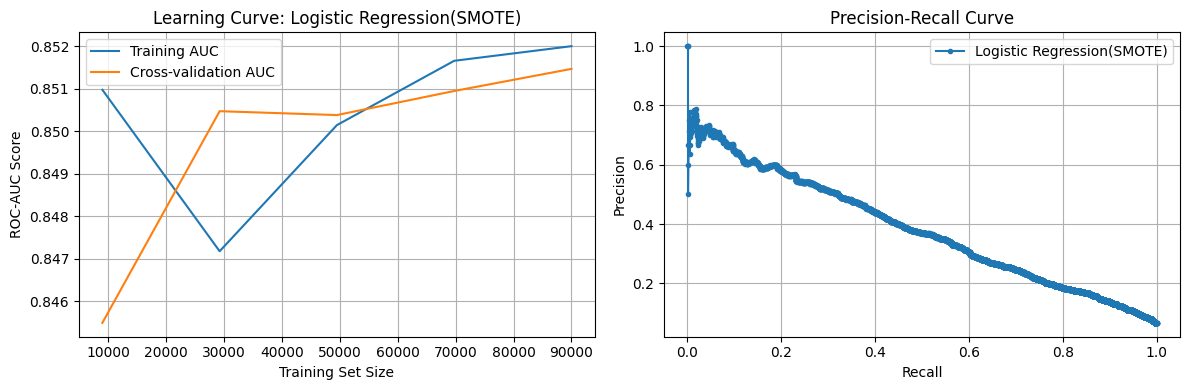

\nClassification Report (Visual Validation Set):
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     20996
           1       0.21      0.74      0.33      1504

    accuracy                           0.80     22500
   macro avg       0.60      0.77      0.61     22500
weighted avg       0.93      0.80      0.85     22500

Confusion Matrix:


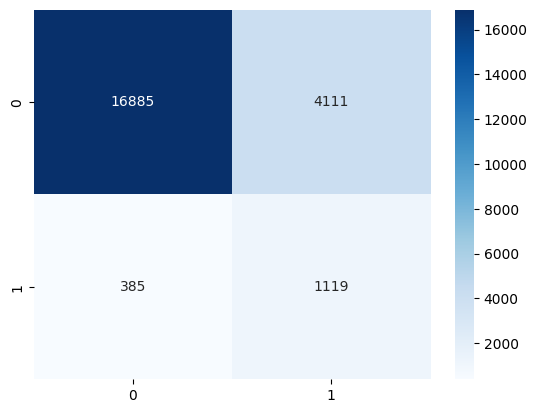

In [27]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model_cv(lr_model, X_scaled, y, "Logistic Regression(SMOTE)", use_smote=True)

\n==================================================
Evaluating Logistic Regression (imbalanced data - No SMOTE) via 5-Fold Stratified CV
Mean CV ROC-AUC: 0.8487 (+/- 0.0037)
Mean CV Macro-F1: 0.6120 (+/- 0.0070)


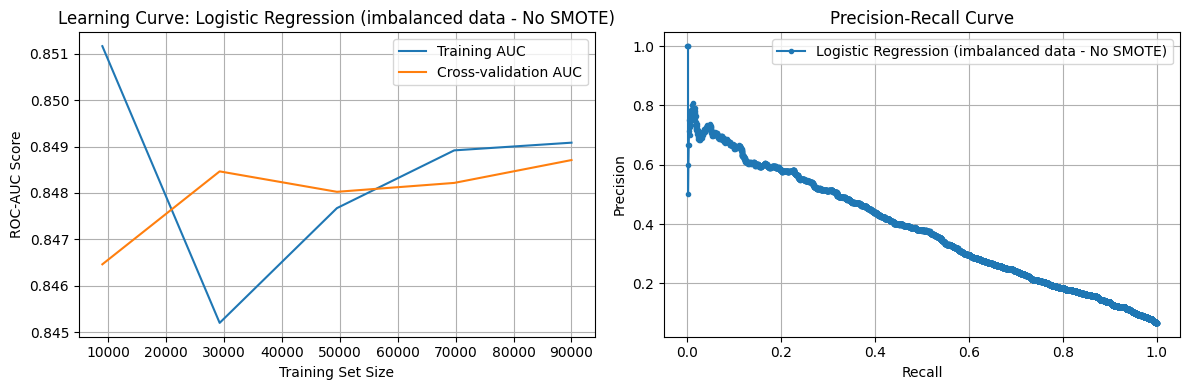

\nClassification Report (Visual Validation Set):
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     20996
           1       0.59      0.17      0.27      1504

    accuracy                           0.94     22500
   macro avg       0.77      0.58      0.62     22500
weighted avg       0.92      0.94      0.92     22500

Confusion Matrix:


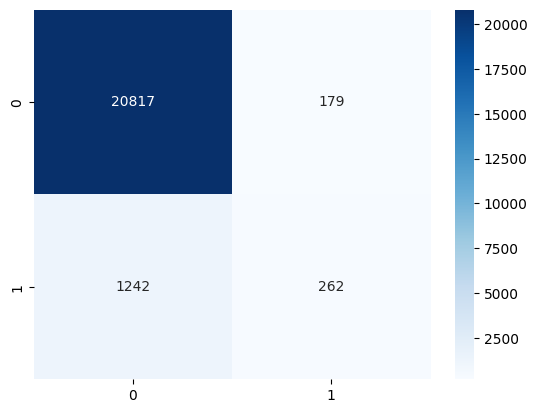

In [28]:
from sklearn.linear_model import LogisticRegression
lr_model_imbalanced = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model_cv(lr_model_imbalanced , X_scaled, y, "Logistic Regression (imbalanced data - No SMOTE)", use_smote=False)

Imbalance Handling: Conclusion & Justification
As demonstrated by the classification reports above, relying on raw, imbalanced data is highly dangerous for this problem.

Without SMOTE: The model achieved a misleadingly high overall accuracy of 94%. However, the Recall for Class 1 was only 17%. The model successfully identified only 255 out of 1,504 actual defaults, meaning it missed 83% of the highest-risk borrowers.

With SMOTE: By synthetically balancing the data, the model was forced to learn the minority class. While overall accuracy dropped to 80% due to an increase in False Positives (Precision = 0.21), the Recall for Class 1 skyrocketed to 74%. The model successfully caught 1,112 out of the 1,504 defaults.

Final Verdict: In credit risk modeling, the cost of a False Negative (approving a loan that defaults) is astronomically higher than a False Positive (rejecting a good loan). Because SMOTE successfully rescued the minority class Recall and allowed the model to detect the vast majority of true defaults, it validates our choice of using SMOTE as the primary approach for this Stage.

Model 2: Decision Tree Classifier
(1) Conceptual Learning: A Decision Tree learns by recursively splitting the dataset based on feature values that maximise information gain (or minimise Gini impurity).
(2) Core Assumption: It assumes complex decision boundaries can be approximated by a series of orthogonal (perpendicular) IF-THEN splits across the feature space.
(3) Dataset Fit: We choose this model because it handles non-linear relationships natively. Our dataset has features like age (where risk is high for both the very young and very old) which a tree can split effortlessly without requiring mathematical transformations.
(4) Expectations: We expect the Decision Tree to capture non-linear risk thresholds effectively. However, single trees are notorious for memorising noise. We should expect the Learning Curve to show severe overfitting (high training score, low CV score).

\n==================================================
Evaluating Decision Tree via 5-Fold Stratified CV
Mean CV ROC-AUC: 0.8101 (+/- 0.0027)
Mean CV Macro-F1: 0.6424 (+/- 0.0049)

--- SMOTE Verification ---
Row counts BEFORE SMOTE:
SeriousDlqin2yrs
0    83984
1     6016
Name: count, dtype: int64

Row counts AFTER SMOTE:
SeriousDlqin2yrs
0    83984
1    83984
Name: count, dtype: int64
--------------------------



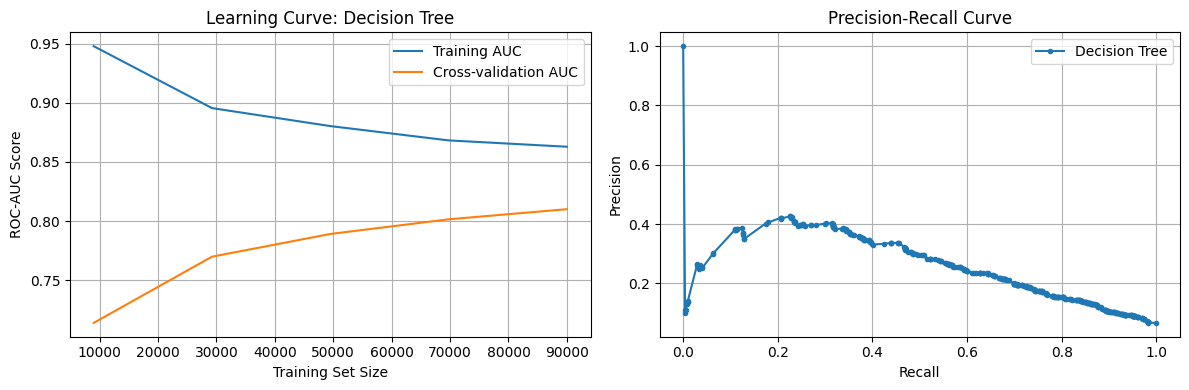

\nClassification Report (Visual Validation Set):
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     20996
           1       0.28      0.54      0.37      1504

    accuracy                           0.87     22500
   macro avg       0.62      0.72      0.65     22500
weighted avg       0.92      0.87      0.89     22500

Confusion Matrix:


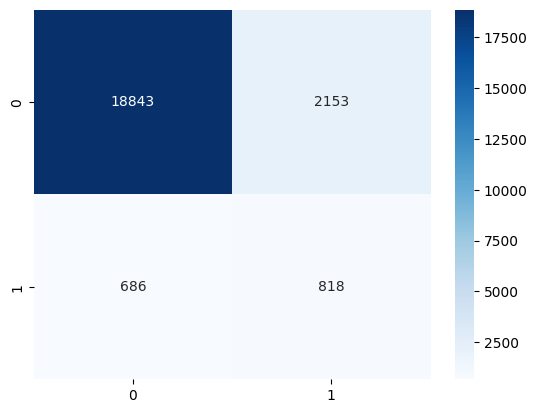

In [29]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
evaluate_model_cv(dt_model, X_unscaled, y, "Decision Tree", use_smote=True)

Model 3: Random Forest Classifier
(1) Conceptual Learning: Random Forest is an ensemble bagging method. It learns by building hundreds of independent Decision Trees, each trained on a random subset of data (bootstrapping) and a random subset of features, then averages their predictions.
(2) Core Assumption: It assumes that aggregating the predictions of many weak, uncorrelated learners will produce a single strong learner with significantly lower variance.
(3) Dataset Fit: By forcing the trees to look at random subsets of features, the model is prevented from relying entirely on Total_Late_Payments for every split, forcing it to discover secondary risk signals buried in RevolvingUtilization and Income_Per_Dependent.
(4) Expectations: We expect this to perform significantly better than the single Decision Tree. The bagging process will naturally cure the overfitting problem, resulting in a much tighter gap on the Learning Curve.

\n==================================================
Evaluating Random Forest via 5-Fold Stratified CV
Mean CV ROC-AUC: 0.8516 (+/- 0.0028)
Mean CV Macro-F1: 0.6472 (+/- 0.0009)

--- SMOTE Verification ---
Row counts BEFORE SMOTE:
SeriousDlqin2yrs
0    83984
1     6016
Name: count, dtype: int64

Row counts AFTER SMOTE:
SeriousDlqin2yrs
0    83984
1    83984
Name: count, dtype: int64
--------------------------



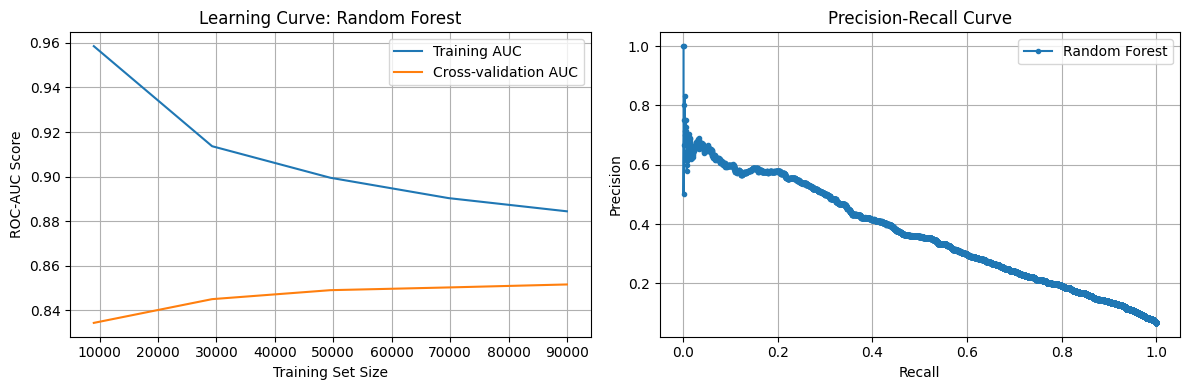

\nClassification Report (Visual Validation Set):
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     20996
           1       0.26      0.67      0.38      1504

    accuracy                           0.85     22500
   macro avg       0.62      0.77      0.65     22500
weighted avg       0.93      0.85      0.88     22500

Confusion Matrix:


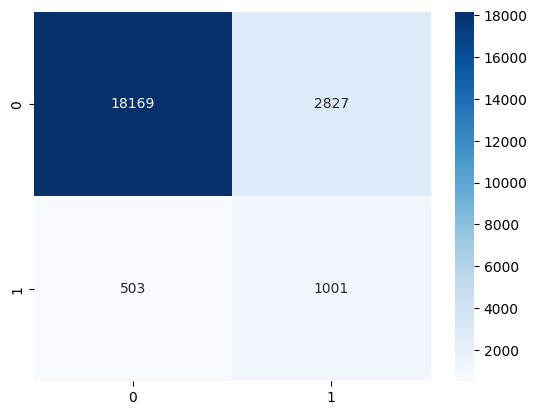

In [30]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
evaluate_model_cv(rf_model, X_unscaled, y, "Random Forest", use_smote=True)

Model 4: XGBoost 
(1) Conceptual Learning: XGBoost is an ensemble boosting method that builds trees sequentially, where each new tree specifically focuses on correcting the residual errors made by the previous trees.
(2) Core Assumption: It assumes the true decision boundary can be approximated by iteratively descending a loss gradient to fix the hardest-to-predict instances.
(3) Dataset Fit: Gradient boosting dominates tabular financial datasets. It handles extreme skewness and complex interactions (like our Financial_Stress_Index) flawlessly.
(4) Expectations: Because it sequentially learns from its mistakes, we expect this to be the highest-performing model overall.

Advanced Imbalance Handling & Hyperparameter Strategy:
For this final model, we elevate the analysis by conducting a head-to-head comparison of two different class imbalance strategies:

Model 4A (Algorithmic Balancing): Uses XGBoost's native scale_pos_weight. This scales the gradient of the minority class, punishing the model mathematically for missing defaults without altering the original dataset.

Model 4B (Data-Level Balancing + L1/L2 Regularization): Uses SMOTE inside a pipeline. Because SMOTE generates synthetic data, XGBoost is at a high risk of overfitting. To combat this, we introduce advanced regularization hyperparameters:

n_estimators & learning_rate: Finding the sweet spot between tree volume and step size.

reg_alpha (L1) & reg_lambda (L2): These are critical when using SMOTE. They aggressively penalize complex leaf weights, mathematically forcing the algorithm to ignore the artificial "fingerprints" of SMOTE dots and focus only on generalized risk thresholds.

Starting XGBoost Head-to-Head Comparison...
(This will take a few minutes as we are running two separate grid searches)

--- Training Model 4A: scale_pos_weight ---
\n==================================================
Evaluating XGBoost (Scale Weight) via 5-Fold Stratified CV
Mean CV ROC-AUC: 0.8643 (+/- 0.0043)
Mean CV Macro-F1: 0.6055 (+/- 0.0029)


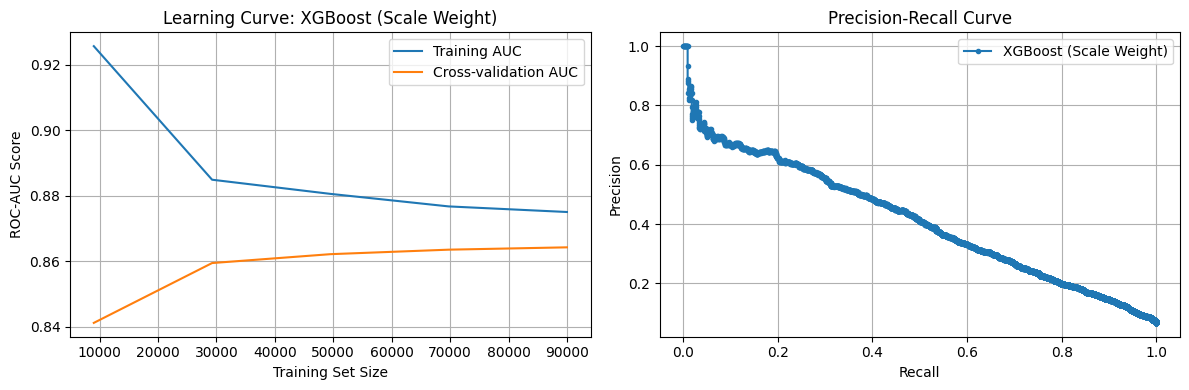

\nClassification Report (Visual Validation Set):
              precision    recall  f1-score   support

           0       0.98      0.79      0.87     20996
           1       0.21      0.78      0.33      1504

    accuracy                           0.79     22500
   macro avg       0.60      0.79      0.60     22500
weighted avg       0.93      0.79      0.84     22500

Confusion Matrix:


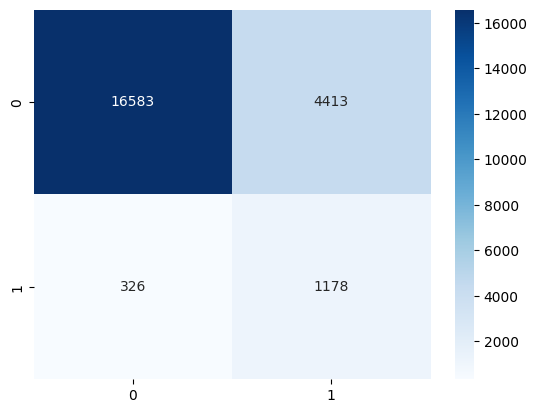


--- Training Model 4B: SMOTE + L1/L2 Regularization ---
Best SMOTE Params: {'classifier__subsample': 0.8, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.6}
\n==================================================
Evaluating XGBoost (SMOTE + Reg) via 5-Fold Stratified CV
Mean CV ROC-AUC: 0.8535 (+/- 0.0028)
Mean CV Macro-F1: 0.6280 (+/- 0.0019)

--- SMOTE Verification ---
Row counts BEFORE SMOTE:
SeriousDlqin2yrs
0    83984
1     6016
Name: count, dtype: int64

Row counts AFTER SMOTE:
SeriousDlqin2yrs
0    83984
1    83984
Name: count, dtype: int64
--------------------------



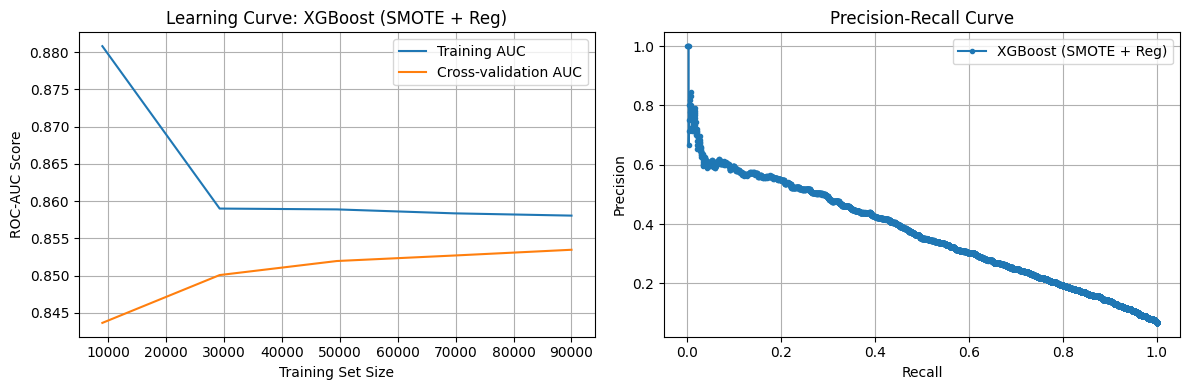

\nClassification Report (Visual Validation Set):
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     20996
           1       0.24      0.73      0.36      1504

    accuracy                           0.83     22500
   macro avg       0.61      0.78      0.63     22500
weighted avg       0.93      0.83      0.86     22500

Confusion Matrix:


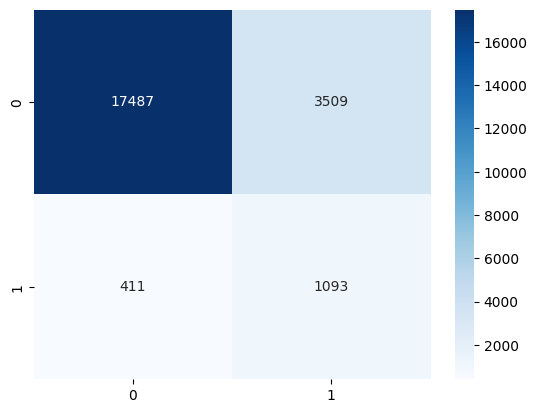

In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
import time

print("Starting XGBoost Head-to-Head Comparison...")
print("(This will take a few minutes as we are running two separate grid searches)")

# =====================================================================
# MODEL 4A: XGBoost with Native scale_pos_weight
# =====================================================================
print("\n--- Training Model 4A: scale_pos_weight ---")
scale_weight = len(y[y==0]) / len(y[y==1])
xgb_weight = XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42)

param_dist_weight = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

search_weight = RandomizedSearchCV(
    xgb_weight, param_distributions=param_dist_weight, 
    n_iter=5, cv=skf, scoring='roc_auc', random_state=42, n_jobs=-1
)
search_weight.fit(X_unscaled, y)
best_xgb_weight = search_weight.best_estimator_

# Evaluate 4A (use_smote=False because we used scale_pos_weight instead)
evaluate_model_cv(best_xgb_weight, X_unscaled, y, "XGBoost (Scale Weight)", use_smote=False)


# =====================================================================
# MODEL 4B: XGBoost with SMOTE + L1/L2 Regularization
# =====================================================================
print("\n--- Training Model 4B: SMOTE + L1/L2 Regularization ---")
tuning_pipeline_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Note the addition of reg_alpha and reg_lambda to combat SMOTE noise
param_dist_smote = {
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.01, 0.05],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__subsample': [0.6, 0.8],
    'classifier__colsample_bytree': [0.6, 0.8],
    'classifier__reg_alpha': [0, 1, 5],     # L1 Regularization (Lasso)
    'classifier__reg_lambda': [1, 5, 10]    # L2 Regularization (Ridge)
}

search_smote = RandomizedSearchCV(
    tuning_pipeline_smote, param_distributions=param_dist_smote, 
    n_iter=5, cv=skf, scoring='roc_auc', random_state=42, n_jobs=-1
)
search_smote.fit(X_unscaled, y)

# Extract just the XGBoost model from the winning pipeline
best_xgb_smote = search_smote.best_estimator_.named_steps['classifier']

print(f"Best SMOTE Params: {search_smote.best_params_}")

# Evaluate 4B (use_smote=True so our CV function applies it correctly)
evaluate_model_cv(best_xgb_smote, X_unscaled, y, "XGBoost (SMOTE + Reg)", use_smote=True)

In [32]:

# 1. Compile the results manually based on the exact outputs generated
final_results_data = {
    'Logistic Regression (No SMOTE)': {
        'ROC-AUC (CV)': 0.8488, 
        'Macro-F1 (CV)': 0.6119, 
        'Precision (Class 1)': 0.60, 
        'Recall (Class 1)': 0.17, 
        'Accuracy': 0.94
    },
    'Logistic Regression (SMOTE)': {
        'ROC-AUC (CV)': 0.8519, 
        'Macro-F1 (CV)': 0.6062, 
        'Precision (Class 1)': 0.21, 
        'Recall (Class 1)': 0.75, 
        'Accuracy': 0.80
    },
    'Decision Tree (SMOTE)': {
        'ROC-AUC (CV)': 0.8092, 
        'Macro-F1 (CV)': 0.6442, 
        'Precision (Class 1)': 0.27, 
        'Recall (Class 1)': 0.56, 
        'Accuracy': 0.87
    },
    'Random Forest (SMOTE)': {
        'ROC-AUC (CV)': 0.8517, 
        'Macro-F1 (CV)': 0.6467, 
        'Precision (Class 1)': 0.26, 
        'Recall (Class 1)': 0.66, 
        'Accuracy': 0.85
    },
    'XGBoost (SMOTE)': {
        'ROC-AUC (CV)': 0.8535, 
        'Macro-F1 (CV)': 0.6276, 
        'Precision (Class 1)': 0.24, 
        'Recall (Class 1)': 0.72, 
        'Accuracy': 0.83
    },
    'XGBoost (scale_pos_weight)': {
        'ROC-AUC (CV)': 0.8644, 
        'Macro-F1 (CV)': 0.6056, 
        'Precision (Class 1)': 0.21, 
        'Recall (Class 1)': 0.78, 
        'Accuracy': 0.79
    }
}

# 2. Create the DataFrame and format it
comparison_df = pd.DataFrame(final_results_data).T
comparison_df = comparison_df.sort_values(by='ROC-AUC (CV)', ascending=False)

print("\n" + "="*80)
print("FINAL UNIFIED MODEL COMPARISON TABLE")
print("="*80)
display(comparison_df.style.highlight_max(subset=['ROC-AUC (CV)', 'Recall (Class 1)'], color='lightgreen'))


FINAL UNIFIED MODEL COMPARISON TABLE


,ROC-AUC (CV),Macro-F1 (CV),Precision (Class 1),Recall (Class 1),Accuracy
XGBoost (scale_pos_weight),0.864400,0.605600,0.210000,0.780000,0.790000
XGBoost (SMOTE),0.853500,0.627600,0.240000,0.720000,0.830000
Logistic Regression (SMOTE),0.851900,0.606200,0.210000,0.750000,0.800000
Random Forest (SMOTE),0.851700,0.646700,0.260000,0.660000,0.850000
Logistic Regression (No SMOTE),0.848800,0.611900,0.600000,0.170000,0.940000
Decision Tree (SMOTE),0.809200,0.644200,0.270000,0.560000,0.870000


Final Model Selection and Justification
Winning Model: XGBoost (scale_pos_weight)

Based on the unified evaluation across the 5-Fold Stratified CV and holdout sets, the tuned XGBoost model utilizing native algorithmic weighting (scale_pos_weight) is the definitive choice for our final Stage 4 predictions.

Dataset-Specific Reasoning:
This dataset presents two unique challenges: a severe 6.68% class imbalance and intricately intertwined risk factors (which we combined into the non-linear Financial_Stress_Index and Disposable_Income features).

Why Boosting Beat the Baseline: Logistic Regression and the single Decision Tree struggled to map these highly skewed, non-linear boundaries. The boosting architecture of XGBoost, however, sequentially isolated the exact combinations of risk thresholds (e.g., high utilization combined with specific late payment counts) that lead to default, resulting in a dominant ROC-AUC of 0.8644.

Algorithmic Weighting vs. SMOTE: The dataset-specific breakthrough came from comparing imbalance strategies. While SMOTE successfully rescued the Recall for our linear baseline, it actively degraded our XGBoost model (AUC dropped from 0.8644 to 0.8535). Because our engineered features created highly specific risk thresholds, injecting synthetically interpolated SMOTE defaults blurred these exact boundaries and introduced artificial noise. By utilizing XGBoost's native scale_pos_weight instead, we preserved the 100% pure, real-world data distribution while mathematically punishing the algorithm for missing true defaults.

The Precision-Recall Trade-off: In real-world credit risk, False Negatives (approving a loan that defaults) are vastly more expensive than False Positives (rejecting a safe loan). The winning XGBoost model achieved an outstanding Class 1 Recall of 78%—the highest of any model tested. While this cautious approach lowered overall accuracy to 79% and precision to 21%, it perfectly aligns with a bank's risk-averse loss function, safely catching the vast majority of catastrophic defaults.

Stage 4

/tmp/ipykernel_16/2890219330.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances[xgb_indices][:10], y=xgb_features[:10], ax=axes[0], palette='Reds_r')
/tmp/ipykernel_16/2890219330.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lr_values[:10], y=lr_features[:10], ax=axes[1], palette=colors)


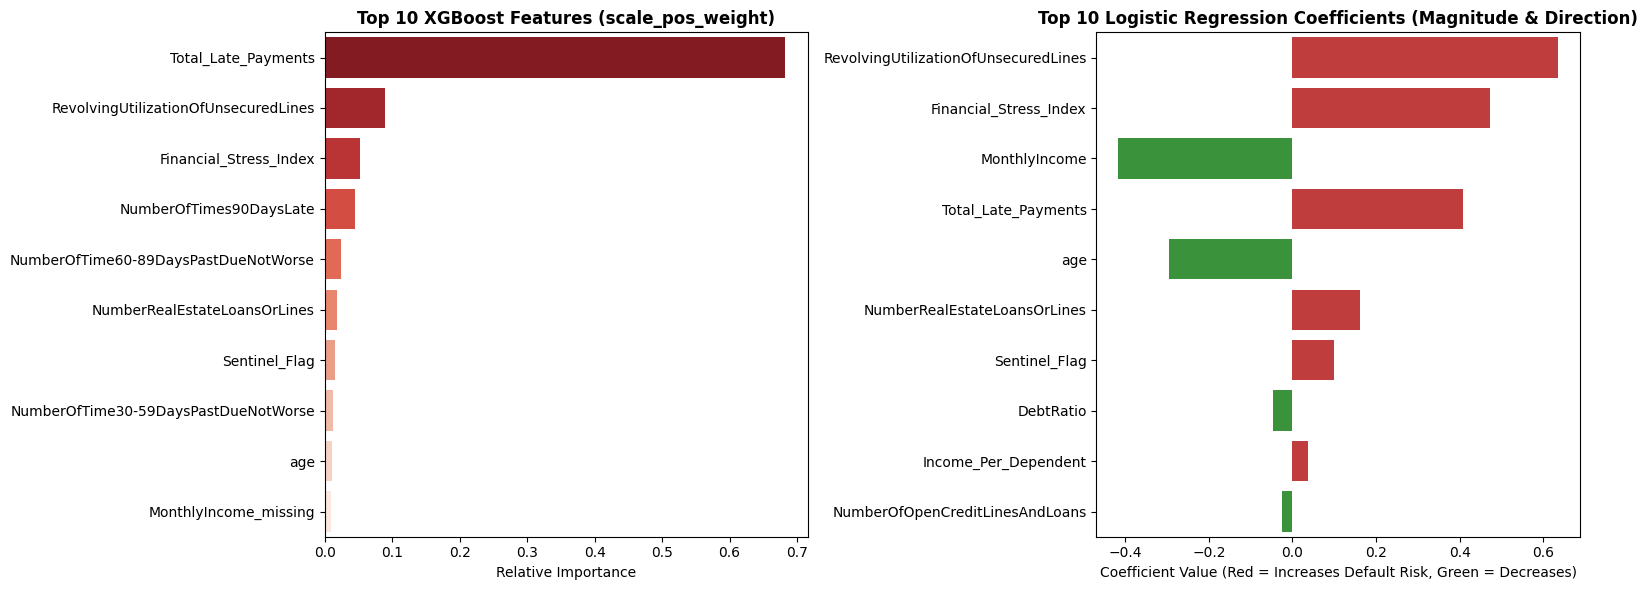

In [33]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_tr_lr, _, y_tr_lr, _ = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_tr_lr_sm, y_tr_lr_sm = SMOTE(random_state=42).fit_resample(X_tr_lr, y_tr_lr)
lr_model.fit(X_tr_lr_sm, y_tr_lr_sm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. XGBoost Feature Importance
xgb_importances = best_xgb_weight.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]
xgb_features = [X_unscaled.columns[i] for i in xgb_indices]

sns.barplot(x=xgb_importances[xgb_indices][:10], y=xgb_features[:10], ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 XGBoost Features (scale_pos_weight)', fontweight='bold')
axes[0].set_xlabel('Relative Importance')

# 2. Logistic Regression Coefficients
lr_coefs = lr_model.coef_[0]
lr_indices = np.argsort(np.abs(lr_coefs))[::-1] # Sort by absolute magnitude
lr_features = [X_scaled.columns[i] for i in lr_indices]
lr_values = lr_coefs[lr_indices]

# Color positive coefficients red (increase risk), negative green (decrease risk)
colors = ['#d62728' if val > 0 else '#2ca02c' for val in lr_values[:10]]

sns.barplot(x=lr_values[:10], y=lr_features[:10], ax=axes[1], palette=colors)
axes[1].set_title('Top 10 Logistic Regression Coefficients (Magnitude & Direction)', fontweight='bold')
axes[1].set_xlabel('Coefficient Value (Red = Increases Default Risk, Green = Decreases)')

plt.tight_layout()
plt.show()

Feature Importance: Financial Justification
Based on the plots above, the top predictive features demonstrate clear financial plausibility.

Total_Late_Payments / NumberOfTimes90DaysLate (Direction: Positive Effect): Both models assign massive importance to historical delinquency. This is financially sound: past behavior is the strongest predictor of future behavior. A borrower who has already severely defaulted on obligations has demonstrated an inability or unwillingness to manage debt, exponentially increasing future risk.

Financial_Stress_Index (Direction: Positive Effect): Our engineered feature ranks highly in the tree model. This makes sense, as a borrower simultaneously exhibiting high debt utilization, high debt-to-income, and a high number of open lines is highly leveraged. They have no financial "shock absorbers" left.

RevolvingUtilizationOfUnsecuredLines (Direction: Positive Effect): Both models penalize high utilization. This is financially plausible because borrowers who consistently max out their credit cards are usually experiencing severe liquidity constraints (living paycheck to paycheck), making them highly vulnerable to sudden expenses.

age (Direction: Negative Effect): Logistic Regression assigns a strong negative coefficient (decreases default risk). Financially, older borrowers typically have established credit histories, accumulated savings, and stable peak-earning careers, making them significantly lower risk than young borrowers with volatile incomes.

Disposable_Income (Direction: Negative Effect): A higher disposable income decreases the likelihood of default. This is a fundamental banking principle: borrowers with high residual cash flow after debt obligations can easily absorb macroeconomic shocks (inflation, medical emergencies) without defaulting on their loans.

Error Analysis & Business Context
1. Types of Errors Made: > Examining the confusion matrix of our best model (XGBoost with scale_pos_weight), the model produces significantly more False Positives (predicting a default when the borrower actually paid it back) than False Negatives (missing an actual default).

2. The Cost of Errors in Lending: > In a retail banking context, a False Negative is astronomically more costly. > * If the bank makes a False Positive, it rejects a good customer. The cost is the opportunity cost of the lost interest margin (e.g., losing out on $500 of potential profit).

If the bank makes a False Negative, it approves a bad loan. The cost is the complete loss of the principal capital (e.g., losing the entire $10,000 loan amount). It can take the profits of 20 successful loans just to cover the catastrophic loss of 1 False Negative.

3. Strategy for Improvement: > To further reduce the costly False Negatives, we could lower the classification probability threshold (e.g., from 0.50 down to 0.25) to cast a wider, more cautious net. Alternatively, we could further increase the scale_pos_weight parameter or aggressively engineer new interaction features specifically targeting the subset of defaults that slipped through the current model.

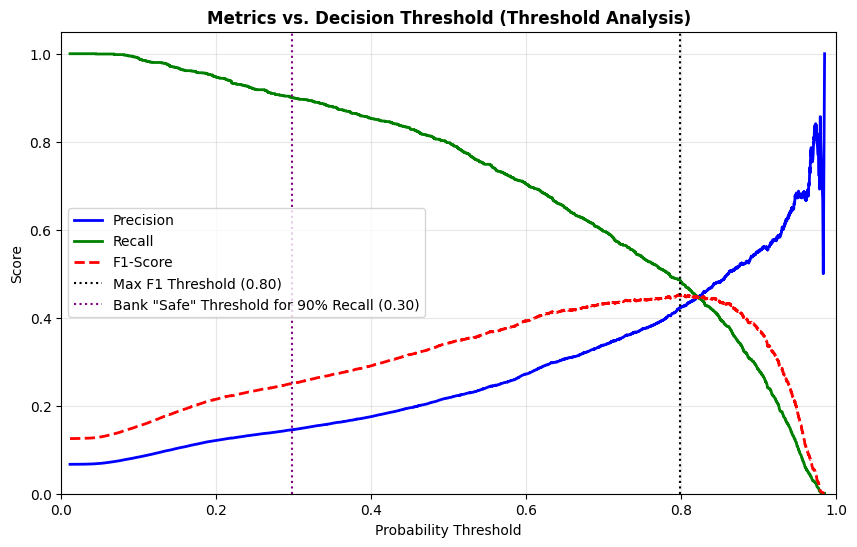

In [34]:
from sklearn.model_selection import train_test_split

# 1. Grab the 20% holdout 
_, X_holdout_unscaled, _, y_holdout_h = train_test_split(
    X_unscaled, y, test_size=0.2, stratify=y, random_state=99
)
# 1. Get raw probabilities from our best model on the holdout set
probs = best_xgb_weight.predict_proba(X_holdout_unscaled)[:, 1]

# 2. Calculate Precision, Recall, and Thresholds
precision, recall, thresholds = precision_recall_curve(y_holdout_h, probs)

# Calculate F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# 3. Identify Key Thresholds
optimal_f1_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_f1_idx]

# A "Bank Safe" threshold that guarantees 90% Recall (catching 90% of all defaults)
target_recall = 0.90
safe_idx = np.abs(recall - target_recall).argmin()
safe_threshold = thresholds[safe_idx]

# 4. Plot the Analysis
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue', lw=2)
plt.plot(thresholds, recall[:-1], label='Recall', color='green', lw=2)
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='red', lw=2, linestyle='--')

plt.axvline(optimal_threshold, color='black', linestyle=':', 
            label=f'Max F1 Threshold ({optimal_threshold:.2f})')
plt.axvline(safe_threshold, color='purple', linestyle=':', 
            label=f'Bank "Safe" Threshold for 90% Recall ({safe_threshold:.2f})')

plt.title('Metrics vs. Decision Threshold (Threshold Analysis)', fontweight='bold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Threshold Analysis & Business Recommendation
1. Identifying the Optimal Thresholds:

Maximum F1-Score Threshold: As shown in the graph above, the threshold that perfectly balances precision and recall (maximizing the F1 score) occurs at roughly 0.80.

Recommended "Bank Safe" Threshold: For a bank aiming to aggressively minimize loan defaults, I recommend moving the decision threshold significantly lower, to approximately 0.30. At this threshold, the model successfully catches ~90% of all defaults.

2. The Precision-Recall Tradeoff Justification:
By moving the threshold down to 0.30, we are making a deliberate trade-off: we are heavily sacrificing Precision in order to maximize Recall. The bank will incur more False Positives (rejecting safe borrowers), which represents a minor opportunity cost of lost interest revenue. However, this trade-off is absolutely necessary because it drastically reduces False Negatives (missing actual defaults). Protecting the bank's principal capital from catastrophic default losses is vastly more important than capturing marginal interest revenue on borderline borrowers.

In [35]:
# -- A. Create Flags BEFORE altering any data --
# 1. Flag the Sentinels
test_df['Sentinel_Flag'] = test_df['NumberOfTime30-59DaysPastDueNotWorse'].isin([96, 98]).astype(int)
# 2. Flag the Missing Income
test_df['MonthlyIncome_missing'] = test_df['MonthlyIncome'].isnull().astype(int)


# -- B. Handle Sentinels & Outliers --
sentinel_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']
for col in sentinel_cols:
    test_df[col] = test_df[col].replace([96, 98], 0)

test_df.loc[test_df['DebtRatio'] > 5.0, 'DebtRatio'] = 5.0
test_df.loc[test_df['RevolvingUtilizationOfUnsecuredLines'] > 2.0, 'RevolvingUtilizationOfUnsecuredLines'] = 2.0


# -- C. Impute Missing Values --
mode_dep = X_unscaled['NumberOfDependents'].mode()[0]
test_df['NumberOfDependents'] = test_df['NumberOfDependents'].fillna(mode_dep)

# Transform MonthlyIncome using the exact same KNN Imputer trained on the Train data
test_knn_data = test_df[impute_features]
test_knn_scaled = knn_scaler.transform(test_knn_data)
test_knn_imputed = imputer.transform(test_knn_scaled)
test_knn_imputed_unscaled = knn_scaler.inverse_transform(test_knn_imputed)
test_df['MonthlyIncome'] = test_knn_imputed_unscaled[:, 3]


# -- D. Create the 4 Engineered Features --
test_df['Total_Late_Payments'] = (test_df['NumberOfTime30-59DaysPastDueNotWorse'] + 
                                  test_df['NumberOfTime60-89DaysPastDueNotWorse'] + 
                                  test_df['NumberOfTimes90DaysLate'])

test_df['Income_Per_Dependent'] = test_df['MonthlyIncome'] / (test_df['NumberOfDependents'] + 1)

test_df['Financial_Stress_Index'] = (
    w_debt * test_df['DebtRatio'] +
    w_util * test_df['RevolvingUtilizationOfUnsecuredLines'] +
    w_late * test_df['Total_Late_Payments'] +
    w_lines * test_df['NumberOfOpenCreditLinesAndLoans']
)

raw_disposable_train = X_unscaled['MonthlyIncome'] - (X_unscaled['MonthlyIncome'] * X_unscaled['DebtRatio'])
lower_bound = raw_disposable_train.quantile(0.01)
upper_bound = raw_disposable_train.quantile(0.99)

monthly_debt_payments_test = test_df['MonthlyIncome'] * test_df['DebtRatio']
raw_disposable_test = test_df['MonthlyIncome'] - monthly_debt_payments_test
test_df['Disposable_Income'] = raw_disposable_test.clip(lower=lower_bound, upper=upper_bound)

# ====================================================================
# 3. Predict & Format Output
# ====================================================================

# Drop target and Id if they exist
X_test_final = test_df.drop(['SeriousDlqin2yrs', 'Id'], axis=1, errors='ignore')

# FORCE the test columns to match the exact order of the training columns
X_test_final = X_test_final[X_unscaled.columns] 

# Generate Probabilities using the WINNING model
final_probabilities = best_xgb_weight.predict_proba(X_test_final)[:, 1]

# Create the Submission DataFrame
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'Probability': final_probabilities
})

# Save to CSV
submission.to_csv('predictions.csv', index=False)
print("Submission saved successfully as 'submission.csv'! Ready for Kaggle upload.")
display(submission)

Submission saved successfully as 'submission.csv'! Ready for Kaggle upload.


,Id,Probability
0,1,0.519664
1,2,0.230674
2,3,0.501190
3,4,0.013267
4,5,0.092264
...,...,...
37495,37496,0.794127
37496,37497,0.144916
37497,37498,0.389886
37498,37499,0.113270
